# Project: Weld Quality Prediction

Course:
Apprentissage Automatique (3IF3010).

Students: 
André Filipe DE MEDEIROS, El Houssine KAMILI, Nicolò DAL MONTE.

The objective of this study is to predict weld quality in steels, an issue that involves billions of euros in the industry, such as in the welding of tubes for wind turbines. Currently, knowledge about weld quality depends heavily on human experience (passed from specialist to specialist). The goal of this study is to manipulate, analyze, and infer patterns related to weld quality through machine learning models studied in the Apprentissage Automatique course using the Weld Database.

Import data

In [1]:
import pandas as pd
import numpy as np

# The file has no header, fields are separated by multiple spaces and missing values are encoded as 'N'
column_names = [
    "Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
    "Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Vanadium_V", "Copper_Cu",
    "Cobalt_Co", "Tungsten_W", "Oxygen_O_ppm", "Titanium_Ti_ppm", "Nitrogen_N_ppm",
    "Aluminium_Al_ppm", "Boron_B_ppm", "Niobium_Nb_ppm", "Tin_Sn_ppm", "Arsenic_As_ppm",
    "Antimony_Sb_ppm", "Current_A", "Voltage_V", "AC_DC", "Electrode_Pos_Neg",
    "Heat_input_kJ_mm", "Interpass_temp_C", "Type_of_weld", "Post_weld_temp_C",
    "Post_weld_time_h", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Charpy_temp_C", "Charpy_toughness_J",
    "Hardness_kg_mm2", "FATT_50_pct", "Primary_ferrite_pct", "Ferrite_second_phase_pct",
    "Acicular_ferrite_pct", "Martensite_pct", "Ferrite_carbide_aggregate_pct", "Weld_ID"
]

df = pd.read_csv("data/welddb.data", sep=r"\s+", header=None, names=column_names, na_values="N")

print(f"Shape: {df.shape[0]} welds x {df.shape[1]} columns")
df.head()

Shape: 1652 welds x 44 columns


,Carbon_C,Silicon_Si,Manganese_Mn,Sulphur_S,Phosphorus_P,Nickel_Ni,Chromium_Cr,Molybdenum_Mo,Vanadium_V,Copper_Cu,...,Charpy_temp_C,Charpy_toughness_J,Hardness_kg_mm2,FATT_50_pct,Primary_ferrite_pct,Ferrite_second_phase_pct,Acicular_ferrite_pct,Martensite_pct,Ferrite_carbide_aggregate_pct,Weld_ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


## Phase 1: Exploratory Data Analysis

The goal of this phase is to understand the database before any preprocessing. Nothing in this phase modifies `df`: every decision about cleaning, imputation or feature selection is taken afterwards, based on what we observe here.

### 1.1 General structure

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Carbon_C                       1652 non-null   float64
 1   Silicon_Si                     1652 non-null   float64
 2   Manganese_Mn                   1652 non-null   float64
 3   Sulphur_S                      1648 non-null   str    
 4   Phosphorus_P                   1642 non-null   float64
 5   Nickel_Ni                      697 non-null    float64
 6   Chromium_Cr                    784 non-null    float64
 7   Molybdenum_Mo                  793 non-null    str    
 8   Vanadium_V                     928 non-null    str    
 9   Copper_Cu                      578 non-null    str    
 10  Cobalt_Co                      129 non-null    str    
 11  Tungsten_W                     75 non-null     str    
 12  Oxygen_O_ppm                   1256 non-null   float64
 13 

### 1.2 Non-numeric values

Many columns are stored as strings even though they should be numeric. We list the values that cannot be converted to numbers, to understand how they are encoded.

In [3]:
categorical_cols = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld", "Weld_ID"]
numeric_candidates = [c for c in df.columns if c not in categorical_cols]

non_numeric = {}
for col in numeric_candidates:
    converted = pd.to_numeric(df[col], errors="coerce")
    bad_values = df.loc[converted.isna() & df[col].notna(), col]
    if len(bad_values) > 0:
        non_numeric[col] = bad_values.value_counts().head(5).to_dict()

for col, values in non_numeric.items():
    print(f"{col}: {values}")

Sulphur_S: {'<0.002': 7}
Molybdenum_Mo: {'<0.01': 2}
Vanadium_V: {'<0.0005': 266, '<0.01': 31, '<5': 9, '<0.005': 2}
Copper_Cu: {'<0.01': 14}
Cobalt_Co: {'<0.01': 21}
Tungsten_W: {'<0.1': 12}
Titanium_Ti_ppm: {'<100': 50, '<0.01': 16, '<5': 2, '<10': 2}
Nitrogen_N_ppm: {'66totndres': 11, '67tot33res': 7, '61tot34res': 7, '54tot24res': 7, '52tot18res': 7}
Aluminium_Al_ppm: {'<5': 343, '<100': 38, '<0.01': 16, '<50': 6}
Boron_B_ppm: {'<5': 395, '<10': 24}
Niobium_Nb_ppm: {'<5': 284, '<100': 9, '<6': 3, '<50': 3}
Tin_Sn_ppm: {'<100': 3, '<10': 2}
Arsenic_As_ppm: {'<100': 8}
Antimony_Sb_ppm: {'<100': 5, '<10': 1}
Interpass_temp_C: {'150-200': 38}
Hardness_kg_mm2: {'203(Hv30)': 2, '157(Hv30)': 2, '144(Hv30)': 2, '154(Hv30)': 2, '224Hv10': 2}
Primary_ferrite_pct: {'<1': 2}


Most of these are detection-limit values (e.g. `<5`, `<0.01`), meaning the element is present below the measurement threshold. Others are malformed entries (e.g. `66totndres` in `Nitrogen_N_ppm`, `203(Hv30)` in `Hardness_kg_mm2`, `150-200` in `Interpass_temp_C`). They will need an explicit treatment in the preprocessing phase.

### 1.3 Missing values

Missing values are encoded as `N` in the original file. We measure how many are missing per column.

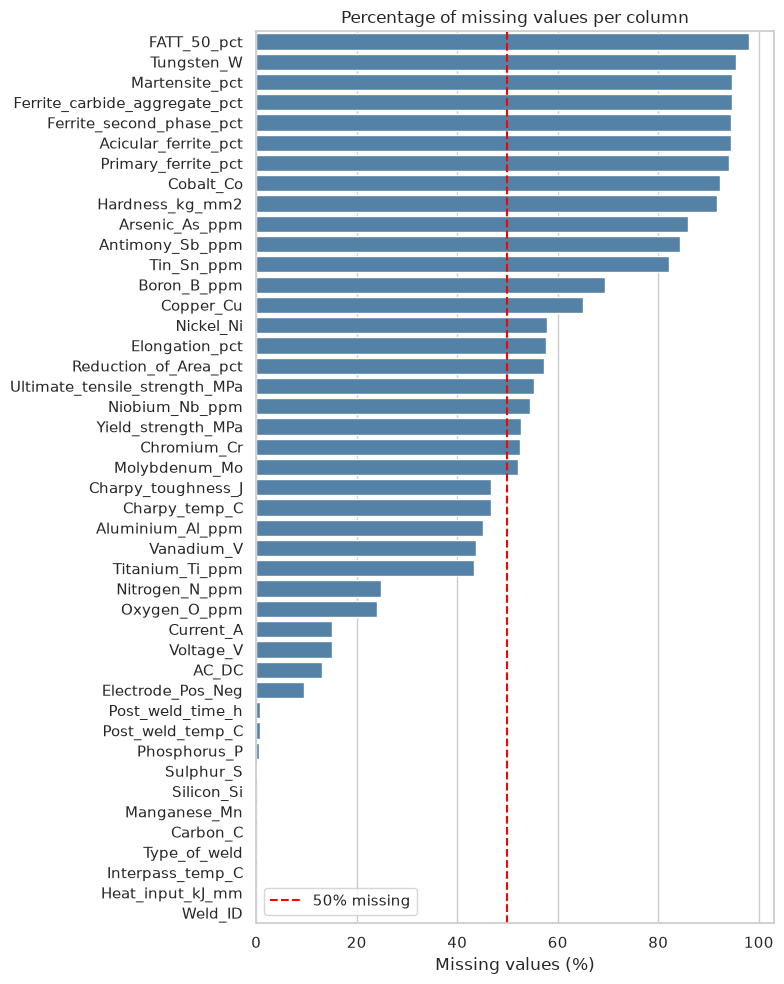

Rows with at least one missing value: 1652 / 1652
Rows with no missing value:           0 / 1652


In [4]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.axvline(50, color="red", linestyle="--", label="50% missing")
plt.xlabel("Missing values (%)")
plt.ylabel("")
plt.title("Percentage of missing values per column")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rows with at least one missing value: {df.isna().any(axis=1).sum()} / {len(df)}")
print(f"Rows with no missing value:           {(~df.isna().any(axis=1)).sum()} / {len(df)}")

### 1.4 Descriptive statistics

For this summary only, we build a temporary numeric copy of the data (`df_num`) where non-convertible entries become NaN. The original `df` is left untouched.

In [5]:
df_num = df.copy()
for col in numeric_candidates:
    df_num[col] = pd.to_numeric(df_num[col], errors="coerce")

df_num[numeric_candidates].describe().T

,count,mean,std,min,25%,50%,75%,max
Carbon_C,1652.0,0.075521,0.023898,0.029,0.06175,0.074,0.086,0.18
Silicon_Si,1652.0,0.328577,0.112455,0.040,0.27000,0.320,0.360,1.14
Manganese_Mn,1652.0,1.202821,0.382137,0.270,0.94000,1.270,1.440,2.25
Sulphur_S,1641.0,0.009561,0.011239,0.001,0.00600,0.007,0.010,0.14
Phosphorus_P,1642.0,0.012952,0.019627,0.002,0.00700,0.010,0.014,0.25
Nickel_Ni,697.0,0.415034,0.786951,0.000,0.00000,0.067,0.260,3.50
Chromium_Cr,784.0,2.101273,3.026548,0.000,0.00000,0.530,2.300,10.20
Molybdenum_Mo,791.0,0.480358,0.477423,0.000,0.00000,0.340,1.010,1.50
Vanadium_V,620.0,0.072443,0.096364,0.000,0.00400,0.015,0.180,0.32
Copper_Cu,564.0,0.176188,0.325897,0.000,0.00000,0.030,0.190,1.63


### 1.5 Distributions of numerical variables

We look for skewness, outliers and suspicious repeated values (sentinel or default values).

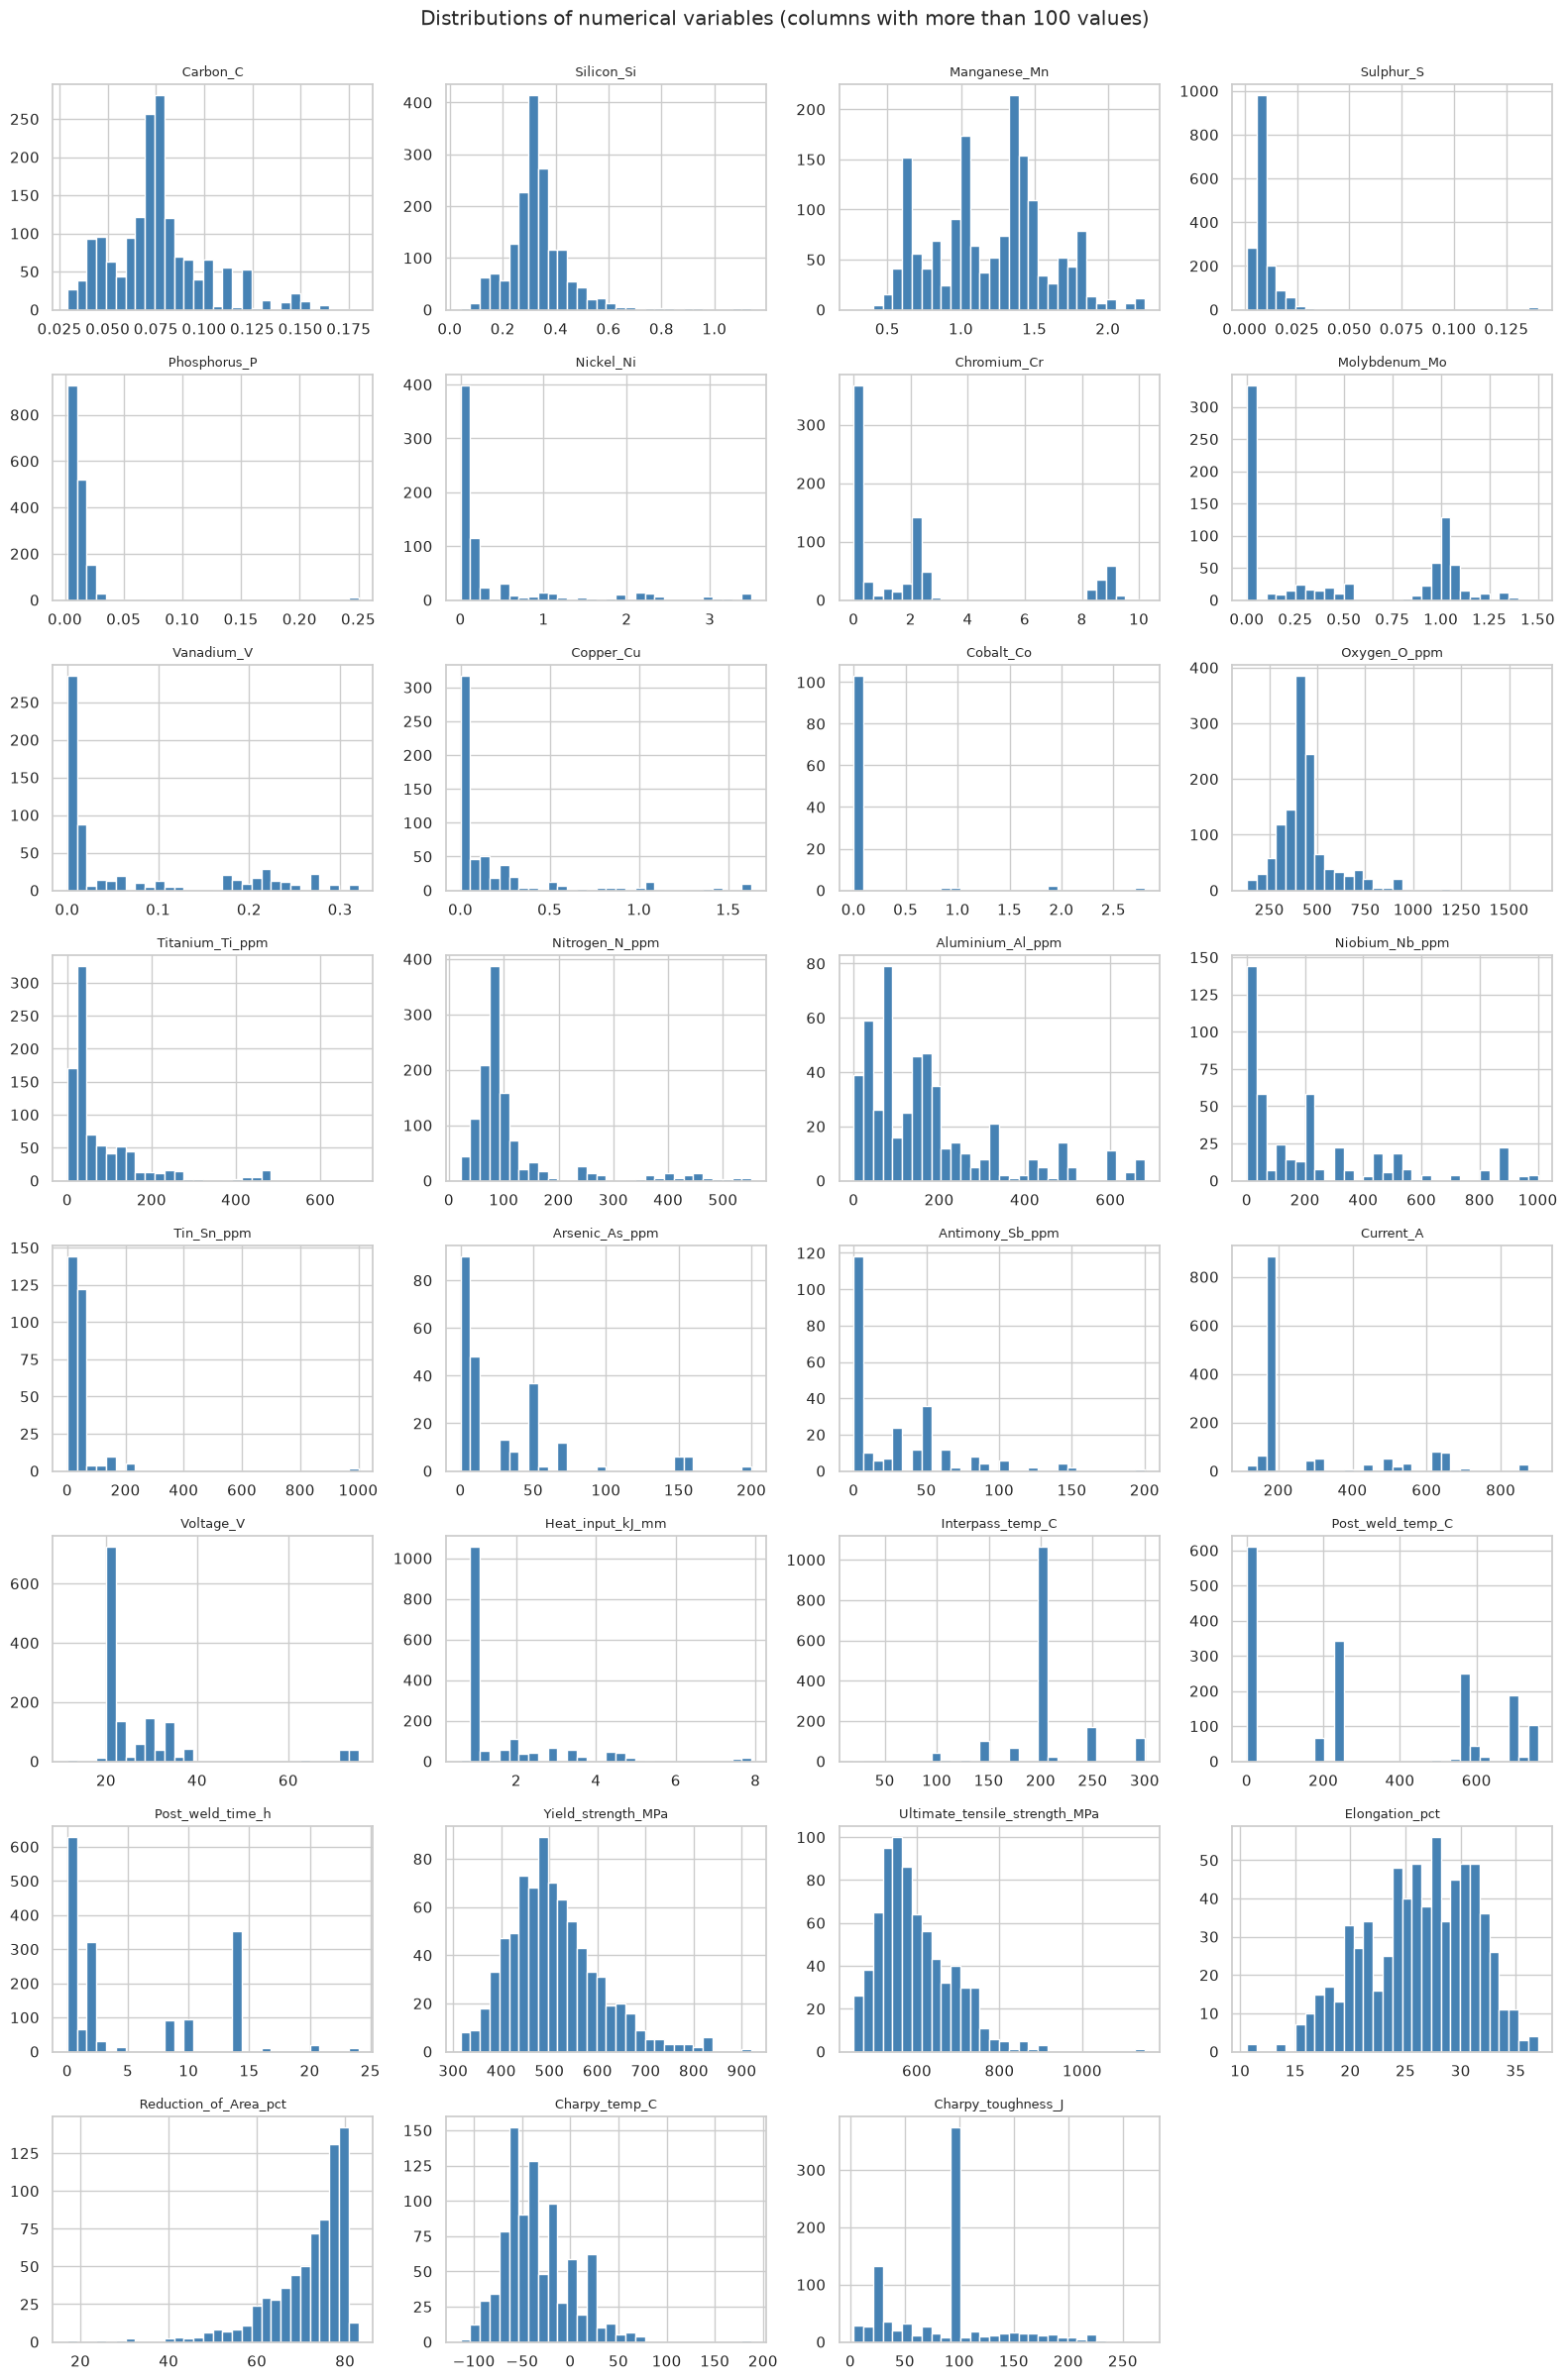

In [6]:
plot_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 100]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df_num[col].dropna(), bins=30, color="steelblue")
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(plot_cols):]:
    ax.axis("off")
plt.suptitle("Distributions of numerical variables (columns with more than 100 values)", y=1.0)
plt.tight_layout()
plt.show()

### 1.6 Categorical variables

In [7]:
for col in ["Type_of_weld", "AC_DC", "Electrode_Pos_Neg"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string(), "\n")

--- Type_of_weld ---
Type_of_weld
MMA      1140
SA        261
FCA        87
TSA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GTAA        4
GMAA        4 

--- AC_DC ---
AC_DC
DC     1395
NaN     215
AC       42 

--- Electrode_Pos_Neg ---
Electrode_Pos_Neg
+      1451
NaN     156
0        38
-         7 



### 1.7 Candidate target variables

The project asks us to identify which variables represent weld quality. The main candidates are the mechanical properties. We compare how many measurements each one has and how they are distributed.

,n_values,pct_missing,min,median,max
Charpy_toughness_J,879,46.8,3.0,100.0,270.0
Yield_strength_MPa,780,52.8,315.0,495.0,920.0
Ultimate_tensile_strength_MPa,738,55.3,447.0,575.5,1151.0
Elongation_pct,700,57.6,10.6,26.8,37.0
Reduction_of_Area_pct,705,57.3,17.0,75.0,83.0
Hardness_kg_mm2,80,95.2,154.0,221.0,265.0


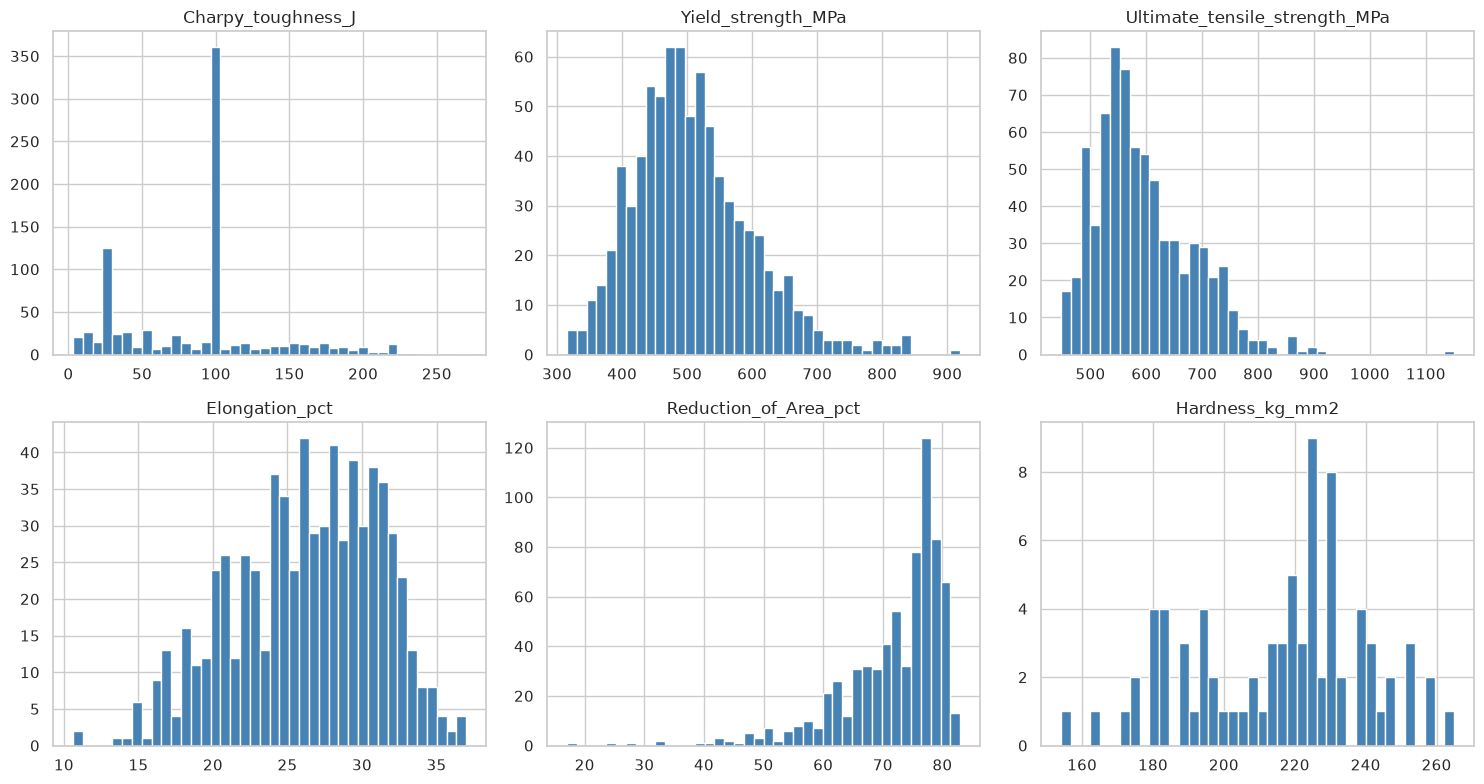

In [8]:
target_candidates = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

summary = pd.DataFrame({
    "n_values": df_num[target_candidates].notna().sum(),
    "pct_missing": (df_num[target_candidates].isna().mean() * 100).round(1),
    "min": df_num[target_candidates].min(),
    "median": df_num[target_candidates].median(),
    "max": df_num[target_candidates].max(),
})
display(summary)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), target_candidates):
    ax.hist(df_num[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Charpy_toughness_J` is the energy absorbed by the weld during an impact test, but it depends on the temperature at which the test was done (`Charpy_temp_C`). Below we check that dependence and how many tests were done at each temperature.

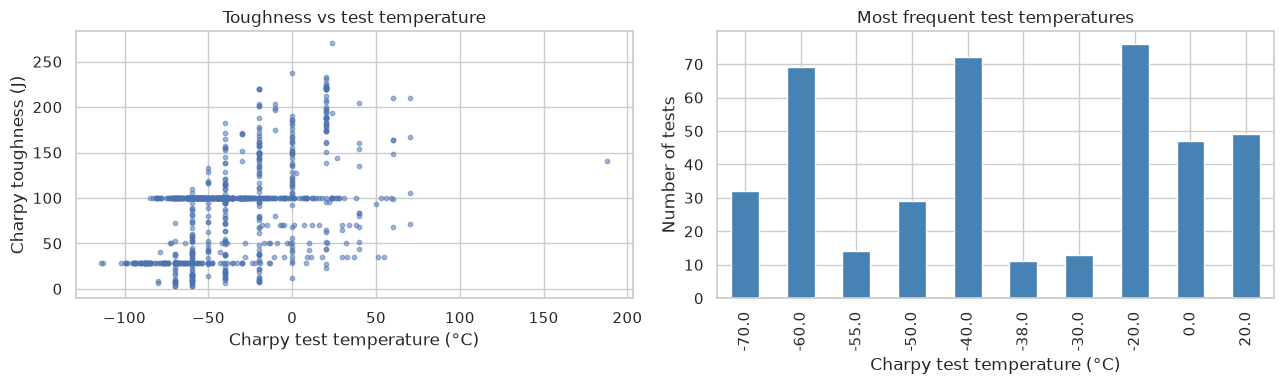

Most frequent toughness values:
Charpy_toughness_J
100.0    356
28.0     118
50.0      16
35.0      12
70.0      12


In [9]:
charpy = df_num[["Charpy_temp_C", "Charpy_toughness_J"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(charpy["Charpy_temp_C"], charpy["Charpy_toughness_J"], s=10, alpha=0.5)
axes[0].set_xlabel("Charpy test temperature (°C)")
axes[0].set_ylabel("Charpy toughness (J)")
axes[0].set_title("Toughness vs test temperature")

charpy["Charpy_temp_C"].value_counts().head(10).sort_index().plot.bar(ax=axes[1], color="steelblue")
axes[1].set_xlabel("Charpy test temperature (°C)")
axes[1].set_ylabel("Number of tests")
axes[1].set_title("Most frequent test temperatures")
plt.tight_layout()
plt.show()

print("Most frequent toughness values:")
print(charpy["Charpy_toughness_J"].value_counts().head(5).to_string())

### 1.8 Correlations

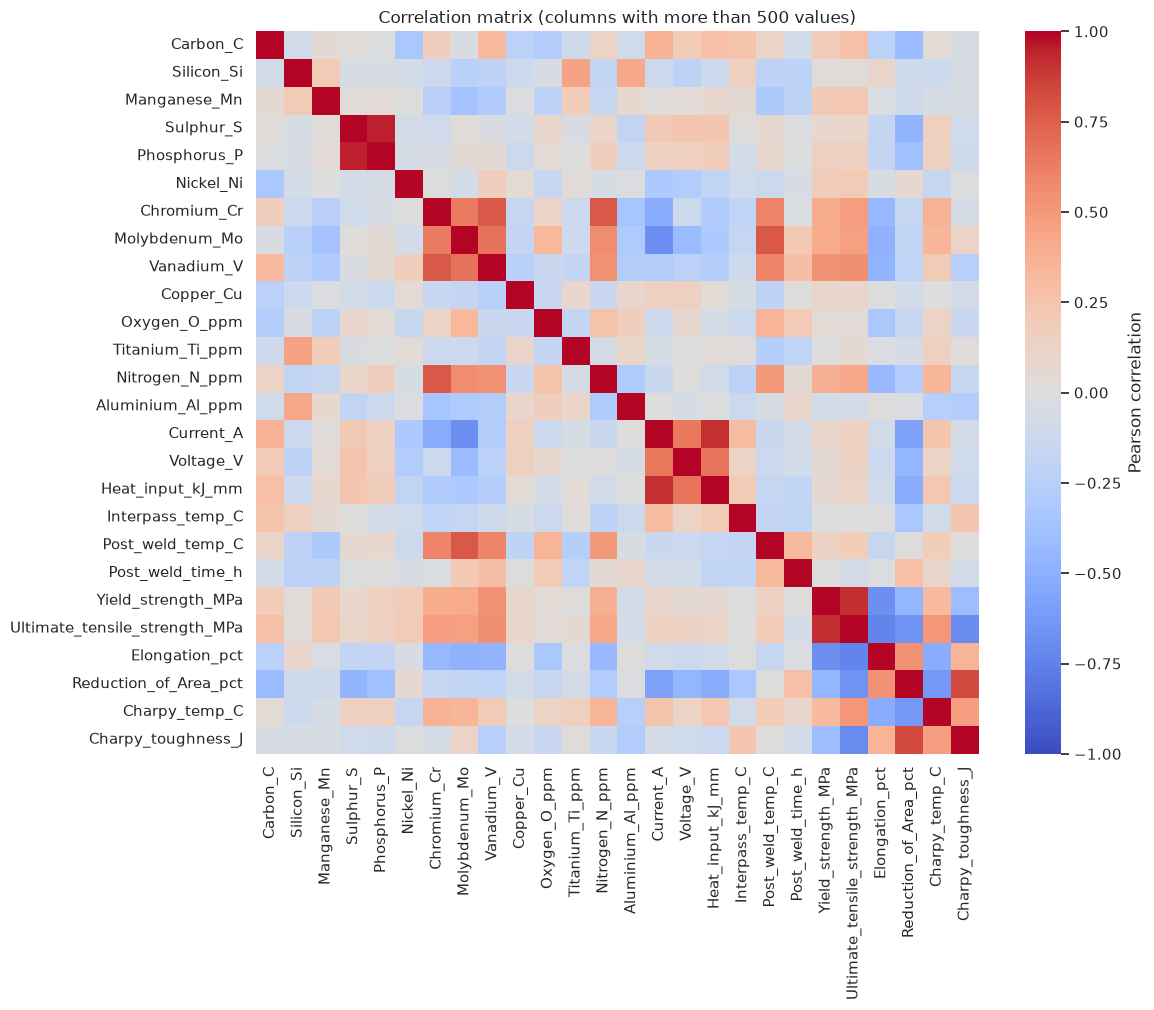

In [10]:
corr_cols = [c for c in numeric_candidates if df_num[c].notna().sum() > 500]
corr = df_num[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation matrix (columns with more than 500 values)")
plt.tight_layout()
plt.show()

### 1.9 Duplicates and weld groups

Several rows can belong to the same weld (same composition and process, different test conditions). This matters for validation: if rows of the same weld land in both train and test sets, the performance is overestimated.

In [11]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Unique Weld_ID values: {df['Weld_ID'].nunique()} / {len(df)}")

# Same composition and process parameters shared by several rows
composition_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
                    "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
group_sizes = df.groupby(composition_cols, dropna=False).size()
print(f"Distinct composition/process combinations: {len(group_sizes)}")
print(f"Rows per combination: median {group_sizes.median():.0f}, max {group_sizes.max()}")

Fully duplicated rows: 0
Unique Weld_ID values: 1490 / 1652
Distinct composition/process combinations: 609
Rows per combination: median 2, max 20


## Phase 2: Preprocessing

Every step below is justified from what we observed in Phase 1. The preprocessing is split in two parts:
- **Deterministic cleaning** (2.1 to 2.4): rules that do not learn anything from the data (parsing strings, choosing columns, defining targets). It is safe to apply it to the whole dataset.
- **Learned transformations** (2.5): imputation, scaling and encoding. They learn parameters (medians, means, categories), so they are wrapped in a scikit-learn `ColumnTransformer` that will be fitted **only on the training folds** during cross-validation, to avoid data leakage.

### 2.1 Cleaning non-standard values

From section 1.2, the non-numeric entries follow four patterns. We convert each one to a number:

| Pattern | Example | Meaning | Treatment |
|---|---|---|---|
| `<x` | `<5`, `<0.0005` | element below the detection limit | half of the limit (`x/2`) |
| `<x` in a `_ppm` column with x < 1 | `<0.01` in `Titanium_Ti_ppm` | the limit is expressed in wt% instead of ppm | convert wt% to ppm (x 10000), then half |
| `<x` in a wt% column with x >= 1 | `<5` in `Vanadium_V` | the limit is expressed in ppm instead of wt% | convert ppm to wt% (/ 10000), then half |
| range `a-b` | `150-200` | interpass temperature range | midpoint |
| number followed by text | `66totndres`, `203(Hv30)` | total value followed by a label | leading number |

The last rule matters: the measured vanadium contents are at most 0.32 wt%, so reading `<5` as 5 wt% would create 9 impossible values (2.5 wt% after halving). The same welds report `<5` ppm for boron and niobium, and `<0.0005` wt% (= 5 ppm) is the most frequent vanadium limit, which confirms that `<5` is a limit in ppm.

Setting detection-limit values to half of the limit is a common convention: it keeps the information "present, but very small" instead of discarding the value or treating it as a missing measurement.

In [12]:
import re


def parse_value(x, col):
    """Convert a raw entry of the weld database to a float (NaN if impossible)."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    try:
        return float(s)
    except ValueError:
        pass
    m = re.fullmatch(r"<\s*([\d.]+)", s)               # detection limit
    if m:
        limit = float(m.group(1))
        if col.endswith("_ppm") and limit < 1:           # limit given in wt% in a ppm column
            limit *= 10000
        elif not col.endswith("_ppm") and limit >= 1:    # limit given in ppm in a wt% column
            limit /= 10000
        return limit / 2
    m = re.fullmatch(r"([\d.]+)-([\d.]+)", s)           # range
    if m:
        return (float(m.group(1)) + float(m.group(2))) / 2
    m = re.match(r"([\d.]+)", s)                         # number followed by text
    if m:
        return float(m.group(1))
    return np.nan


df_clean = df.copy()
for col in numeric_candidates:
    df_clean[col] = df_clean[col].map(lambda x: parse_value(x, col))

# Sanity check: parsing must not create new missing values
new_nans = (df_clean[numeric_candidates].isna().sum() - df[numeric_candidates].isna().sum())
print("New NaN introduced by the parsing:", int(new_nans.sum()))
print("Maximum of Vanadium_V after parsing (wt%):", df_clean["Vanadium_V"].max())
print("Columns still stored as strings:", [c for c in numeric_candidates if df_clean[c].dtype == object or str(df_clean[c].dtype) == "str"])

New NaN introduced by the parsing: 0
Maximum of Vanadium_V after parsing (wt%): 0.32
Columns still stored as strings: []


### 2.2 Features and quality variables

The preprocessing below is **independent of the choice of the quality variables**: that choice is made after the PCA, once we understand the structure of the data. For this reason:

- All the welds are kept (no row is removed because a target is missing).
- The measurements that could represent quality (mechanical properties) stay in `df_clean`, untouched and out of the features. The candidates are listed in `candidate_quality_cols`.
- `Charpy_temp_C` is not a feature for now: it is the temperature of the Charpy test, not a property of the weld. If toughness is chosen as a quality variable, it will have to be considered explicitly (it changes the toughness strongly).

### 2.3 Feature selection

- **Kept:** chemical composition and welding process parameters (the first 30 columns): they are known before the weld is tested.
- **Not features, because they are measured after welding** (they are results of the weld, not inputs, and would leak the quality): mechanical properties, hardness, FATT50 and microstructure.
- **Removed because they are almost empty:** columns with more than 80% missing values (Co, W, Sn, As, Sb). Imputing so many values would mostly invent data.
- **`Weld_ID`** is not a feature: it is an identifier.
- **Weld groups.** Rows with identical composition and process parameters are tests of the same weld. We build a group id so that cross-validation can keep them in the same fold (`GroupKFold`).
- **Rare weld types** (not MMA, SA, FCA, TSA, ShMA) are grouped into `Other`, because categories with fewer than 20 rows are too small to be useful.

In [13]:
MAX_MISSING = 0.80          # drop features with more than 80% missing values

# Composition and process parameters: first 30 columns (Carbon_C ... Post_weld_time_h)
weld_features = list(df_clean.columns[:30])
missing_ratio = df_clean[weld_features].isna().mean()
dropped_features = missing_ratio[missing_ratio > MAX_MISSING].index.tolist()
features = [c for c in weld_features if c not in dropped_features]

print(f"Dropped for more than {MAX_MISSING:.0%} missing values: {dropped_features}")
print(f"Kept {len(features)} features: {features}")

# Group id: same composition and process parameters = same weld
group_cols = ["Carbon_C", "Silicon_Si", "Manganese_Mn", "Sulphur_S", "Phosphorus_P",
              "Current_A", "Voltage_V", "Heat_input_kJ_mm"]
df_clean["Group"] = df_clean.groupby(group_cols, dropna=False).ngroup()

# Rare weld types (fewer than 20 rows) are grouped into "Other"
main_welds = ["MMA", "SA", "FCA", "TSA", "ShMA"]
df_clean["Type_of_weld"] = df_clean["Type_of_weld"].where(df_clean["Type_of_weld"].isin(main_welds), "Other")

# Candidate quality variables: kept aside, to be chosen after the PCA
candidate_quality_cols = [
    "Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa",
    "Elongation_pct", "Reduction_of_Area_pct", "Hardness_kg_mm2",
]

Dropped for more than 80% missing values: ['Cobalt_Co', 'Tungsten_W', 'Tin_Sn_ppm', 'Arsenic_As_ppm', 'Antimony_Sb_ppm']
Kept 25 features: ['Carbon_C', 'Silicon_Si', 'Manganese_Mn', 'Sulphur_S', 'Phosphorus_P', 'Nickel_Ni', 'Chromium_Cr', 'Molybdenum_Mo', 'Vanadium_V', 'Copper_Cu', 'Oxygen_O_ppm', 'Titanium_Ti_ppm', 'Nitrogen_N_ppm', 'Aluminium_Al_ppm', 'Boron_B_ppm', 'Niobium_Nb_ppm', 'Current_A', 'Voltage_V', 'AC_DC', 'Electrode_Pos_Neg', 'Heat_input_kJ_mm', 'Interpass_temp_C', 'Type_of_weld', 'Post_weld_temp_C', 'Post_weld_time_h']


### 2.4 Feature matrix

`X` contains the features of **all** the welds. The candidate quality variables are not part of it. Once the quality variables are chosen, the rows where they are available are the labeled data, and the others are the unlabeled data of the semi-supervised part.

In [14]:
X = df_clean[features]
groups = df_clean["Group"]

print(f"X: {X.shape[0]} welds x {X.shape[1]} features, {groups.nunique()} weld groups")

# Availability of each candidate quality variable (information only, no row is removed)
pd.DataFrame({
    "n_values": df_clean[candidate_quality_cols].notna().sum(),
    "pct_missing": (df_clean[candidate_quality_cols].isna().mean() * 100).round(1),
})

X: 1652 welds x 25 features, 609 weld groups


,n_values,pct_missing
Charpy_toughness_J,879,46.8
Yield_strength_MPa,780,52.8
Ultimate_tensile_strength_MPa,738,55.3
Elongation_pct,700,57.6
Reduction_of_Area_pct,705,57.3
Hardness_kg_mm2,138,91.6


### 2.5 Missing values, categorical variables and scaling

These steps learn parameters from the data, so they are defined here as an unfitted `ColumnTransformer` and will be fitted inside the cross-validation of the models.

**Missing values**
- *Alloying elements* (`Nickel_Ni`, `Chromium_Cr`, `Molybdenum_Mo`, `Copper_Cu`): they are mostly absent in plain carbon-manganese steels, so a missing value most likely means "not added". They are filled with **0**.
- *Other numerical variables*: filled with the **median** (robust to the skewed distributions seen in section 1.5).
- In both cases a **missing indicator** column is added, so a model can still use the fact that a value was not reported.
- *Categorical variables*: missing values become their own category `missing`.

**Categorical variables.** `AC_DC`, `Electrode_Pos_Neg` and `Type_of_weld` are **one-hot encoded** (they have no natural order); unseen categories at prediction time are ignored.

**Scaling.** Variables have very different units and ranges (wt%, ppm, A, V, °C, kJ/mm), so we apply **standardization (z-score)**. It is required for PCA and for distance-based or linear models (KNN, SVM, linear regression, label propagation). Tree-based models do not need it, but it does no harm and lets us use the same preprocessing for every model. Skewed variables are not log-transformed, to keep the variables easy to interpret.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

alloy_cols_all = ["Nickel_Ni", "Chromium_Cr", "Molybdenum_Mo", "Copper_Cu"]
categorical_features_all = ["AC_DC", "Electrode_Pos_Neg", "Type_of_weld"]


def make_preprocessor(feature_list):
    alloy = [c for c in alloy_cols_all if c in feature_list]
    categorical = [c for c in categorical_features_all if c in feature_list]
    numeric = [c for c in feature_list if c not in alloy + categorical]
    return ColumnTransformer([
        ("alloy", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=0, add_indicator=True)),
            ("scale", StandardScaler()),
        ]), alloy),
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical),
    ]).set_output(transform="pandas")


preprocessor = make_preprocessor(features)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('alloy', ...), ('numeric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fea

### 2.6 Check of the preprocessing

To verify that the pipeline works we fit it on all the welds. **This is only an inspection** (and the input of the PCA, which is exploratory): when models are evaluated, the pipeline must be fitted on the training folds only.

In [16]:
X_t = preprocessor.fit_transform(X)

print(f"{X.shape[1]} raw features -> {X_t.shape[1]} columns after preprocessing")
print(f"Remaining NaN: {int(X_t.isna().sum().sum())}")

X_t.describe().T[["mean", "std", "min", "max"]].round(2).head(12)

25 raw features -> 52 columns after preprocessing
Remaining NaN: 0


,mean,std,min,max
alloy__Nickel_Ni,-0.0,1.0,-0.32,6.04
alloy__Chromium_Cr,-0.0,1.0,-0.43,3.94
alloy__Molybdenum_Mo,-0.0,1.0,-0.56,3.11
alloy__Copper_Cu,-0.0,1.0,-0.29,7.56
alloy__missingindicator_Nickel_Ni,0.0,1.0,-1.17,0.85
alloy__missingindicator_Chromium_Cr,0.0,1.0,-1.05,0.95
alloy__missingindicator_Molybdenum_Mo,-0.0,1.0,-1.04,0.96
alloy__missingindicator_Copper_Cu,-0.0,1.0,-1.36,0.73
numeric__Carbon_C,0.0,1.0,-1.95,4.37
numeric__Silicon_Si,-0.0,1.0,-2.57,7.22


## Phase 3: Principal Component Analysis (PCA)

The PCA is used to build intuition about the structure of the data, not to evaluate any model. It does not use any target, so it is applied to **all** the welds, on the preprocessed matrix `X_t`. It needs the three properties that the preprocessing provides: no missing values, only numbers, and a common scale (otherwise the variables with large numbers, such as the current, would dominate).

### 3.1 Input of the PCA and explained variance

`X_t` has 52 columns of three kinds: scaled numerical variables, missing indicators (0/1) and one-hot categories (0/1). The binary columns describe *which information was reported* or *which category a weld belongs to*, not a physical quantity. We therefore fit the PCA twice and compare:

- **All columns** (52).
- **Numerical and alloy variables only** (22): the physical measurements (composition and process parameters), without indicators and categories.

In [17]:
from sklearn.decomposition import PCA

numeric_cols = [c for c in X_t.columns
                if c.startswith(("alloy__", "numeric__")) and "missingindicator" not in c]
X_pca_all = X_t
X_pca_num = X_t[numeric_cols]

pca_all = PCA().fit(X_pca_all)
pca_num = PCA().fit(X_pca_num)


def n_components_for(pca, threshold):
    return int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= threshold)) + 1


pd.DataFrame({
    "n_columns": [X_pca_all.shape[1], X_pca_num.shape[1]],
    "PC1 (%)": [pca_all.explained_variance_ratio_[0] * 100, pca_num.explained_variance_ratio_[0] * 100],
    "PC2 (%)": [pca_all.explained_variance_ratio_[1] * 100, pca_num.explained_variance_ratio_[1] * 100],
    "PC1+PC2 (%)": [pca_all.explained_variance_ratio_[:2].sum() * 100, pca_num.explained_variance_ratio_[:2].sum() * 100],
    "components for 80%": [n_components_for(pca_all, 0.80), n_components_for(pca_num, 0.80)],
    "components for 90%": [n_components_for(pca_all, 0.90), n_components_for(pca_num, 0.90)],
}, index=["All columns", "Numerical and alloy only"]).round(1)

,n_columns,PC1 (%),PC2 (%),PC1+PC2 (%),components for 80%,components for 90%
All columns,52,16.3,11.6,27.9,14,20
Numerical and alloy only,22,20.3,14.3,34.6,11,14


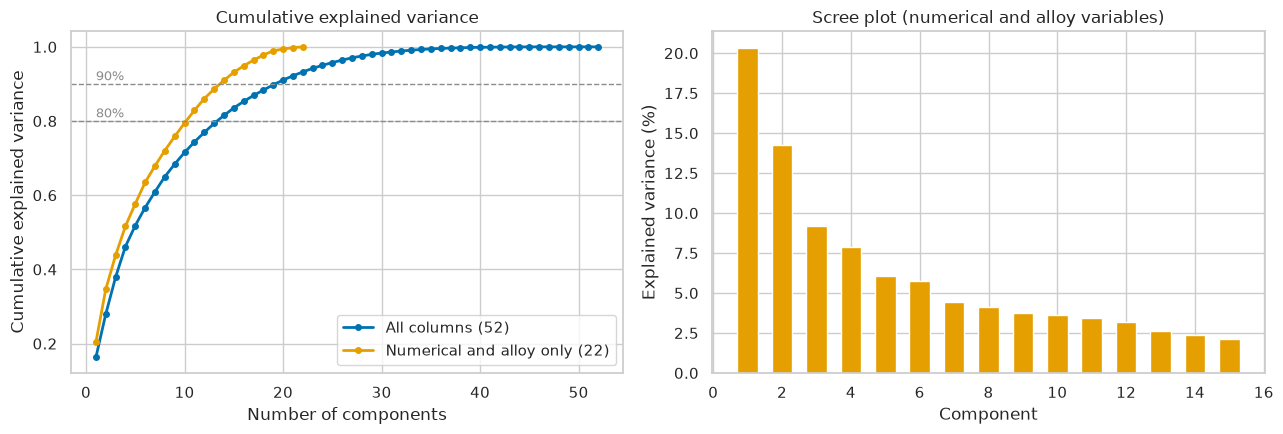

In [18]:
BLUE, ORANGE, GREY = "#0072B2", "#E69F00", "#8c8c8c"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for pca, label, color in [(pca_all, f"All columns ({X_pca_all.shape[1]})", BLUE),
                          (pca_num, f"Numerical and alloy only ({X_pca_num.shape[1]})", ORANGE)]:
    cumulative = np.cumsum(pca.explained_variance_ratio_)
    axes[0].plot(range(1, len(cumulative) + 1), cumulative, marker="o", markersize=4, linewidth=2,
                 color=color, label=label)
for threshold in (0.80, 0.90):
    axes[0].axhline(threshold, color=GREY, linestyle="--", linewidth=1)
    axes[0].text(1, threshold + 0.01, f"{threshold:.0%}", color=GREY, fontsize=9)
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("Cumulative explained variance")
axes[0].legend(loc="lower right")

n_show = 15
axes[1].bar(range(1, n_show + 1), pca_num.explained_variance_ratio_[:n_show] * 100, color=ORANGE, width=0.6)
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Explained variance (%)")
axes[1].set_title("Scree plot (numerical and alloy variables)")

plt.tight_layout()
plt.show()

### 3.2 Welds in the plane of the first two components

From here on we use the numerical and alloy version, which is the one that can be interpreted physically. The same plane is colored four ways: by weld type, by two candidate quality variables (yield strength and Charpy toughness) and by whether the heat input is exactly 1.0 kJ/mm. Welds without a measurement are shown in grey. The quality variables are used here only as colors: the choice of the quality variables is made later.

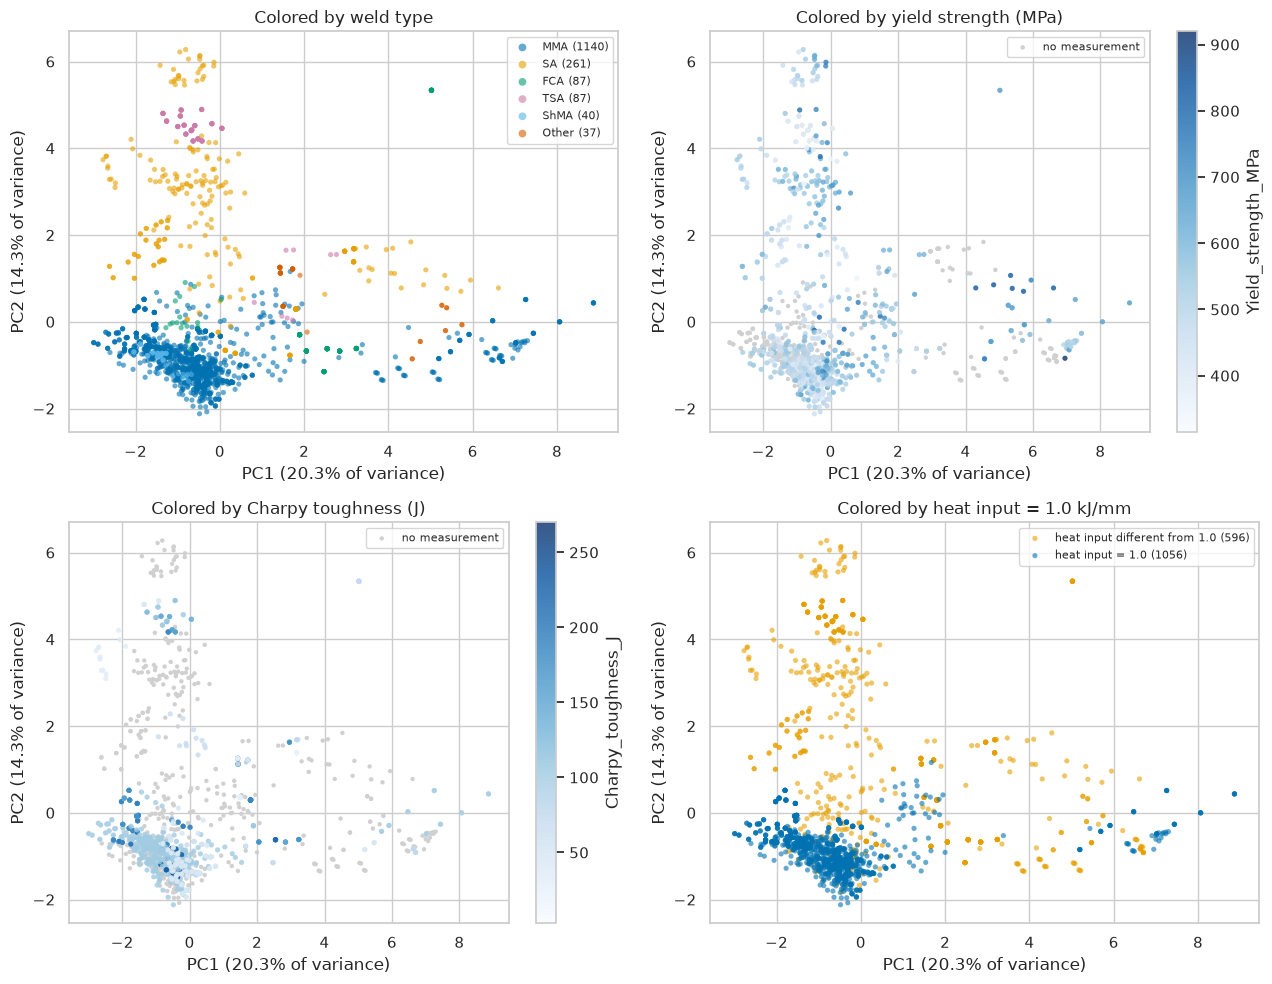

In [19]:
Z = pd.DataFrame(pca_num.transform(X_pca_num)[:, :4], columns=["PC1", "PC2", "PC3", "PC4"], index=X_t.index)
var_pct = pca_num.explained_variance_ratio_ * 100

weld_order = main_welds + ["Other"]
weld_colors = dict(zip(weld_order, ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# a) weld type
ax = axes[0, 0]
for weld in weld_order:
    mask = df_clean["Type_of_weld"] == weld
    ax.scatter(Z.loc[mask, "PC1"], Z.loc[mask, "PC2"], s=14, alpha=0.6, color=weld_colors[weld],
               label=f"{weld} ({mask.sum()})", edgecolor="none")
ax.set_title("Colored by weld type")
ax.legend(fontsize=8, markerscale=1.5)

# b) and c) continuous candidate quality variables
for ax, col, title in [(axes[0, 1], "Yield_strength_MPa", "Colored by yield strength (MPa)"),
                       (axes[1, 0], "Charpy_toughness_J", "Colored by Charpy toughness (J)")]:
    has_value = df_clean[col].notna()
    ax.scatter(Z.loc[~has_value, "PC1"], Z.loc[~has_value, "PC2"], s=10, color="#d0d0d0", edgecolor="none",
               label="no measurement")
    sc = ax.scatter(Z.loc[has_value, "PC1"], Z.loc[has_value, "PC2"], s=14, c=df_clean.loc[has_value, col],
                    cmap="Blues", edgecolor="none", alpha=0.8)
    plt.colorbar(sc, ax=ax, label=col)
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")

# d) heat input equal to 1.0
ax = axes[1, 1]
is_one = df_clean["Heat_input_kJ_mm"] == 1.0
ax.scatter(Z.loc[~is_one, "PC1"], Z.loc[~is_one, "PC2"], s=14, alpha=0.6, color=ORANGE, edgecolor="none",
           label=f"heat input different from 1.0 ({(~is_one).sum()})")
ax.scatter(Z.loc[is_one, "PC1"], Z.loc[is_one, "PC2"], s=14, alpha=0.6, color=BLUE, edgecolor="none",
           label=f"heat input = 1.0 ({is_one.sum()})")
ax.set_title("Colored by heat input = 1.0 kJ/mm")
ax.legend(fontsize=8)

for ax in axes.ravel():
    ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}% of variance)")
    ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}% of variance)")
plt.tight_layout()
plt.show()

### 3.3 Loadings: what the components represent

The loadings are the weights of each original variable in a component. A large positive or negative weight means that the variable contributes strongly to it; variables with weights of the same sign move together along that component.

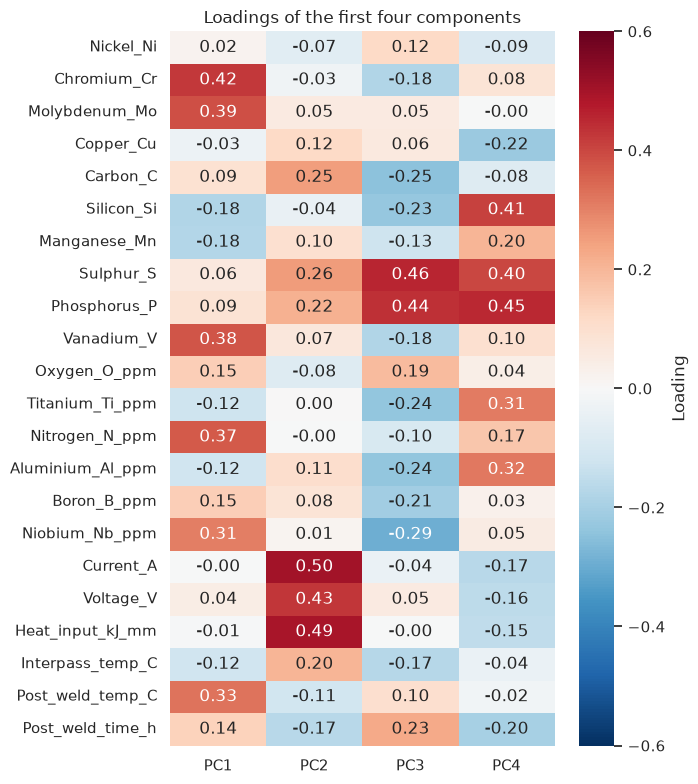

PC1: Chromium_Cr (+0.42), Molybdenum_Mo (+0.39), Vanadium_V (+0.38), Nitrogen_N_ppm (+0.37), Post_weld_temp_C (+0.33)
PC2: Current_A (+0.50), Heat_input_kJ_mm (+0.49), Voltage_V (+0.43), Sulphur_S (+0.26), Carbon_C (+0.25)
PC3: Sulphur_S (+0.46), Phosphorus_P (+0.44), Niobium_Nb_ppm (-0.29), Carbon_C (-0.25), Titanium_Ti_ppm (-0.24)
PC4: Phosphorus_P (+0.45), Silicon_Si (+0.41), Sulphur_S (+0.40), Aluminium_Al_ppm (+0.32), Titanium_Ti_ppm (+0.31)


In [20]:
feature_names = [c.split("__")[-1] for c in numeric_cols]
loadings = pd.DataFrame(pca_num.components_[:4].T, index=feature_names, columns=["PC1", "PC2", "PC3", "PC4"])

plt.figure(figsize=(7, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
            cbar_kws={"label": "Loading"})
plt.title("Loadings of the first four components")
plt.tight_layout()
plt.show()

for pc in loadings.columns:
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(5)
    print(f"{pc}: " + ", ".join(f"{name} ({value:+.2f})" for name, value in top.items()))

### 3.4 Link between the components and the candidate quality variables

Correlation of each component with the candidate quality variables and with the heat-input indicator. Each correlation uses only the welds where the variable is available, so the number of welds differs. These are linear correlations and are only indicative.

In [21]:
quality_for_pca = ["Charpy_toughness_J", "Yield_strength_MPa", "Ultimate_tensile_strength_MPa", "Elongation_pct"]

rows = {}
for col in quality_for_pca:
    mask = df_clean[col].notna()
    rows[col] = {"n": int(mask.sum())} | {pc: np.corrcoef(Z.loc[mask, pc], df_clean.loc[mask, col])[0, 1]
                                          for pc in Z.columns}
rows["Heat input = 1.0 (indicator)"] = {"n": len(df_clean)} | {
    pc: np.corrcoef(Z[pc], (df_clean["Heat_input_kJ_mm"] == 1.0).astype(float))[0, 1] for pc in Z.columns}

pd.DataFrame(rows).T.round(2)

,n,PC1,PC2,PC3,PC4
Charpy_toughness_J,879.0,-0.14,-0.10,-0.03,-0.10
Yield_strength_MPa,780.0,0.36,0.12,-0.19,0.14
Ultimate_tensile_strength_MPa,738.0,0.42,0.19,-0.24,0.15
Elongation_pct,700.0,-0.46,-0.13,0.10,-0.12
Heat input = 1.0 (indicator),1652.0,-0.27,-0.64,-0.11,0.06


### 3.5 Interpretation

**Dimensionality.** There is no dominant direction: the first two components explain only about 35% of the variance, and 11 components (out of 22) are needed for 80% and 14 for 90%. The data are not low-dimensional, so the PCA is not useful to reduce the number of features here; it is useful to understand the structure.

**Missing indicators.** When they are included, the first components are dominated by the missing indicators: the PCA mostly separates welds by *which elements were reported* (different studies report different elements), not by metallurgy. This is why the interpretation uses only the numerical and alloy variables.

**What the components represent** (numerical and alloy version):
- **PC1 (about 20%): alloy content and heat treatment.** Chromium, molybdenum, vanadium, nitrogen and post-weld temperature on one side; silicon and manganese on the other. FCA welds and the rare weld types are high on this component.
- **PC2 (about 14%): welding energy.** Current, heat input and voltage. Submerged-arc welds (SA, TSA) are high, manual welds (MMA, ShMA) are low.
- **PC3 (about 9%): impurities.** Sulphur and phosphorus, which vary together (correlation 0.95 in the EDA).
- **PC4 (about 8%):** phosphorus, silicon, sulphur, aluminium and titanium.

The weld families separate in the PC1-PC2 plane. This supports using `GroupKFold` and suggests that a model may learn the weld family rather than the effect of the variables.

**Heat input.** The indicator "heat input = 1.0" has a correlation of about -0.64 with PC2: the value 1.0 is the manual-welding side of the energy axis, so it is largely redundant with the weld type. It still carries information for the other processes (values such as 2.0, 3.3, 4.6), so it is kept for now; the decision can be revisited with the team.

**Link with quality (indicative).** Strength and elongation are related to PC1 (yield +0.36, tensile +0.42, elongation -0.46): more alloyed and heat-treated welds are stronger and less ductile, which is the strength/ductility trade-off already seen in the EDA. Charpy toughness is only weakly related to any of the first four components (largest absolute correlation about 0.14): toughness is not explained by the main directions of variance of composition and process. This suggests that toughness is harder to predict from these variables (probably non-linear relations and interactions, plus the effect of the test temperature and of the 28 J values), whereas strength and elongation have a clearer link with composition.

**Consequences for the next steps.**
- Standardization is justified: without it the current and the voltage would dominate the first components.
- The quality variables will be chosen taking this into account: the strength variables are better linked to the features than the toughness.
- The PCA components are not used as inputs of the models; the original variables are kept for interpretability.


## Phase 4: Quality variables and prediction strategy

### 4.1 What represents weld quality

A good weld has to be **strong** and **tough** at the same time. These are two different properties, measured with different tests, and they move in opposite directions: the correlation between Charpy toughness and tensile strength is -0.70 (and -0.41 with yield strength). A single number cannot describe quality, so we define quality along **two dimensions**, each with its own variables and its own model:

| Dimension | Quality variables | Role |
|---|---|---|
| **Strength** (main) | `Yield_strength_MPa`, `Ultimate_tensile_strength_MPa`, `Elongation_pct` | Main objective |
| **Toughness** (secondary) | `Charpy_toughness_J` | Second objective |

### 4.2 Why these variables

**Strength is the main objective** because the data support it best:
- 665 welds have the three measurements together, belonging to 465 independent weld groups.
- The three variables are strongly related (yield-tensile 0.91, yield-elongation -0.71, tensile-elongation -0.74), so predicting them together in one multi-target model is natural. Yield and tensile strength measure the resistance; elongation measures the ductility and shows the strength/ductility trade-off.
- There is no test-temperature effect and no suspicious repeated value.
- The PCA shows a clear link with composition: they are related to PC1, the alloy content and heat treatment axis (yield +0.36, tensile +0.42, elongation -0.46).

**Toughness is the secondary objective** because it is the standard criterion of weld quality (resistance to brittle fracture, relevant for the cold-weather applications of the project, such as wind turbine tubes), but it is harder to model:
- Toughness depends strongly on the test temperature (median 39 J at -60 °C, 188 J at +20 °C), so `Charpy_temp_C` must be taken into account.
- 356 of the 879 values are exactly 100 J at every test temperature, which is physically implausible (probably a default value); 118 values are 28 J, concentrated at low temperatures (probably an acceptance threshold). If the 100 J values are removed, 523 welds remain (200 independent groups), and 23% of them are 28 J.
- In the PCA it is only weakly related to the main components (largest absolute correlation 0.14): it is not explained by the main directions of variance of composition and process. We expect weaker results than for strength.

### 4.3 Why two models and not one

Charpy and strength are measured on almost disjoint sets of welds: only 144 welds have Charpy, yield and tensile together (35 if the Charpy temperature is also fixed). A single multi-target model would keep less than 10% of the data. Two models let each one use all the welds where its own variables are available, and the two predictions can still be compared to discuss the strength/toughness trade-off.

### 4.4 What is discarded, and why

- **Hardness** (138 values after the parsing of section 2.1, 92% missing) and the **microstructure** variables and FATT50 (fewer than 100 values): too few measurements.
- **Reduction of area** (705 values): it is a result of the same tensile test and correlates 0.83 with Charpy toughness; it is not an input and does not add a different quality dimension.
- **Weld_ID** and **Group**: identifiers, not variables.

### 4.5 Prediction strategy

1. **Features:** the 25 composition and process variables, preprocessed by `preprocessor` (Phase 2). For the toughness model, `Charpy_temp_C` is added as a feature, because it is a known condition of the test and changes the result strongly.
2. **Strength model:** multi-target regression of the three variables on the 665 welds that have all of them.
3. **Toughness model:** regression of `Charpy_toughness_J` on the welds with a Charpy value and a test temperature. The documentation of the database does not flag the 100 J and 28 J values as default values, so the main experiment keeps them; a sensitivity analysis removes the 100 J values (section 5.6). A classification (toughness above or below a threshold) is not used, because no acceptance threshold is documented.
4. **Validation:** nested cross-validation with `GroupKFold` on the weld groups (welds with identical composition and process parameters stay in the same fold; in Phase 5, groups sharing a `Weld_ID` are also merged). Without it, rows of the same weld would appear in the training and test sets and the scores would be overestimated. The preprocessing must be inside a `Pipeline`, so that it is fitted on the training folds only.
5. **Metrics:** R², RMSE and MAE for each target, weighted by weld group. The targets have different units, so they are evaluated separately (the choice is discussed in section 6.1).
6. **Unlabeled data:** the 840 welds without any strength measurement (and the 147 with partial measurements) have all the input features and are the material for the semi-supervised part. It applies to the strength model only: none of the 773 welds without a Charpy value has a test temperature, which is a required input of the toughness model. Their distribution differs from the labeled welds (for example, nickel is more frequent and higher among them), so pseudo-labels on nickel-rich welds are extrapolations.

### 4.6 Limitations to keep in mind

- Only 465 (strength) and about 200 (toughness) independent welds: cross-validation estimates will be noisy and complex models are risky.
- The weld types are unbalanced (about 70% of the strength data are MMA welds): a model may learn the weld family rather than the effect of the variables.
- The values 100 J and 28 J in the Charpy data are not real measurements and may bias the toughness model.
- Linear correlations and the PCA only describe linear structure; the relations with the quality variables are probably non-linear.

## Phase 5: Modelling and validation

We now address the two tasks defined in Phase 4: predicting the tensile properties of a weld (strength model) and its Charpy energy at a known test temperature (toughness model). This phase defines the models, the validation protocol and the semi-supervised method, and stores the out-of-fold predictions. Their comparison is the subject of Phase 6.

### 5.1 Data preparation

The modelling reuses exactly the objects of Phases 2 to 4: the cleaned table `df_clean`, the 25 features of section 2.3 and the factory `make_preprocessor` of section 2.5. The preprocessor fitted on all welds in section 2.6 (the input of the PCA) is **not** reused: every fit starts from a fresh preprocessor, fitted on the training rows only. As concluded in section 3.5, the PCA components are not used as inputs.

For the splits we add `Validation_Group`. It merges the `Group` ids of section 2.3 that share the same (non-missing) `Weld_ID`, transitively. Rows linked by their identifier therefore cannot end up on both sides of a fold. The rule is conservative: an identifier may have been reused for different conditions. Inputs, targets and the `Group` column are unchanged.

In [22]:
from pathlib import Path
import json
import platform
import time
import warnings
from IPython.display import display
import sklearn

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/welddb.data").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the project folder (it must contain data/welddb.data).")
RESULTS_DIR = ROOT / "results"

STRENGTH = ["Yield_strength_MPa", "Ultimate_tensile_strength_MPa", "Elongation_pct"]
CHARPY = ["Charpy_toughness_J"]
SEED = 42

In [23]:
def load_ml_data():
    """Copy of df_clean with Validation_Group: the Groups that share a Weld_ID are merged (union-find)."""
    data = df_clean.copy()
    parent = {int(g): int(g) for g in data["Group"].unique()}

    def find(g):
        while parent[g] != g:
            parent[g] = parent[parent[g]]
            g = parent[g]
        return g

    for _, rows in data.dropna(subset=["Weld_ID"]).groupby("Weld_ID"):
        gs = [int(g) for g in rows["Group"].unique()]
        for g in gs[1:]:
            a, b = find(gs[0]), find(g)
            parent[max(a, b)] = min(a, b)
    data["Validation_Group"] = data["Group"].map(lambda g: find(int(g)))
    assert data.groupby("Group")["Validation_Group"].nunique().max() == 1
    assert data.groupby("Weld_ID")["Validation_Group"].nunique().max() == 1
    return data


def tasks(data, features):
    complete = data[STRENGTH].notna().all(axis=1)
    charpy = data["Charpy_toughness_J"].notna() & data["Charpy_temp_C"].notna()
    charpy_features = features + ["Charpy_temp_C"]
    return {
        "strength": {"targets": STRENGTH, "features": features,
                     "labeled": data.index[complete], "unlabeled": data.index[~complete]},
        "charpy": {"targets": CHARPY, "features": charpy_features,
                   "labeled": data.index[charpy],
                   "unlabeled": data.index[data["Charpy_toughness_J"].isna() & data["Charpy_temp_C"].notna()]},
        # Sensitivity analysis (section 5.6): the 100 J values are removed, not turned into unlabeled rows
        "charpy_without_100": {"targets": CHARPY, "features": charpy_features,
                               "labeled": data.index[charpy & data["Charpy_toughness_J"].ne(100)],
                               "unlabeled": data.index[:0]},
    }


def availability(data, specs):
    return pd.DataFrame([{
        "task": name, "n_labeled": len(s["labeled"]),
        "n_validation_groups": data.loc[s["labeled"], "Validation_Group"].nunique(),
        "n_original_groups": data.loc[s["labeled"], "Group"].nunique(),
        "n_unlabeled_eligible": len(s["unlabeled"]), "n_features": len(s["features"]),
    } for name, s in specs.items()])

In [24]:
df_ml = load_ml_data()
features_ml = list(features)
task_specs = tasks(df_ml, features_ml)
print(f"{len(df_ml)} rows; {len(features_ml)} features kept in Phase 2.")
print("Groups (section 2.3):", df_ml["Group"].nunique(), "- validation groups:", df_ml["Validation_Group"].nunique())
display(availability(df_ml, task_specs))

1652 rows; 25 features kept in Phase 2.
Groups (section 2.3): 609 - validation groups: 600


,task,n_labeled,n_validation_groups,n_original_groups,n_unlabeled_eligible,n_features
0,strength,665,462,465,987,25
1,charpy,879,328,328,0,26
2,charpy_without_100,523,200,200,0,26


### Available measurements

The strength task uses the **665 rows** that have the three properties, in **462 validation groups** (465 groups of section 2.3). The 987 other rows are 840 rows without any of these measurements and 147 rows with partial measurements. For the semi-supervised method we only use their inputs, and ignore the measurements already known for the partial rows.

For Charpy, **879 rows** have both an energy and a test temperature. No row without a measured energy has a test temperature, so there is no usable unlabeled data for this task: adding these rows would require inventing a test temperature. The semi-supervised method is therefore applied to the strength task only.

The [MAP documentation](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html) states that `N` means "not reported", not zero. We keep the conventions of Phase 2 (alloying elements imputed to zero, half of the detection limit), with a missing indicator so that the models can still distinguish an imputed value from a measured one.

In [25]:
complete_strength = df_ml[STRENGTH].notna().all(axis=1)
none_strength = df_ml[STRENGTH].isna().all(axis=1)
partial_strength = ~complete_strength & ~none_strength
assert (complete_strength.sum(), none_strength.sum(), partial_strength.sum()) == (665, 840, 147)
assert len(task_specs["charpy"]["unlabeled"]) == 0
display(pd.DataFrame({"status of the three strength targets": ["complete", "all missing", "partial"],
                      "rows": [complete_strength.sum(), none_strength.sum(), partial_strength.sum()]}))

,status of the three strength targets,rows
0,complete,665
1,all missing,840
2,partial,147


### 5.2 Supervised models

We compare methods that rely on different assumptions: additive relations, proximity between observations, kernels and partitions by trees.

| Model | Course link | Hyperparameter grid |
|---|---|---|
| Mean (`Dummy_mean`) | Constant baseline | none |
| Linear regression (`OLS`) | CM0, TD1 | none |
| Ridge | Regularisation, CM2 | α: 0.1 / 1 / 10 / 100 / 1000 |
| KNN | Nearest neighbours, CM5 | 3 / 7 / 15 neighbours; uniform or distance weights |
| SVR with RBF kernel | SVM adapted to regression, CM5, TD3 | C: 1 / 10 / 100; ε: 0.05 / 0.2; γ = `scale` |
| Decision tree (CART) | Trees, CM3 | depth 3 / 6 / unlimited; leaf 2 / 8 |
| Bagging | Aggregation of trees | 100 trees; sample 0.6 / 1; depth 6 / unlimited; leaf 2 |
| Random forest | Random rows and features | 150 trees; feature fraction 0.5 / 1; leaf 2 / 8 |
| ExtraTrees | Additional randomisation of the thresholds | 150 trees; feature fraction 0.5 / 1; leaf 2 / 8; no bootstrap |

The targets stay continuous: we do not create a quality class from an arbitrary threshold. The inputs are imputed, encoded and standardised inside each fit. The three strength targets are also standardised inside each fit (`TransformedTargetRegressor`), and the predictions are converted back to MPa or %. Without this step the MPa would dominate the elongation in the multi-output trees, which share their splits between outputs. The SVR is fitted separately for each target (`MultiOutputRegressor`).

The grids are fixed before any score is computed and remain small, given the number of independent groups. The Ridge grid goes up to α = 1000 so that the selected value is not systematically on the edge of the grid.

In [26]:
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import BaggingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor


def supervised_specs():
    return {
        "Dummy_mean": (DummyRegressor(strategy="mean"), {}),
        "OLS": (LinearRegression(), {}),
        "Ridge": (Ridge(), {"alpha": [0.1, 1, 10, 100, 1000]}),
        "KNN": (KNeighborsRegressor(), {"n_neighbors": [3, 7, 15], "weights": ["uniform", "distance"]}),
        "SVR_RBF": (MultiOutputRegressor(SVR(kernel="rbf")),
                    {"estimator__C": [1, 10, 100], "estimator__epsilon": [0.05, 0.2]}),
        "DecisionTree": (DecisionTreeRegressor(random_state=SEED),
                         {"max_depth": [3, 6, None], "min_samples_leaf": [2, 8]}),
        "Bagging": (BaggingRegressor(estimator=DecisionTreeRegressor(min_samples_leaf=2),
                                     n_estimators=100, random_state=SEED, n_jobs=1),
                    {"max_samples": [0.6, 1.0], "estimator__max_depth": [6, None]}),
        "RandomForest": (RandomForestRegressor(n_estimators=150, random_state=SEED, n_jobs=1),
                         {"max_features": [0.5, 1.0], "min_samples_leaf": [2, 8]}),
        "ExtraTrees": (ExtraTreesRegressor(n_estimators=150, random_state=SEED, n_jobs=1),
                       {"max_features": [0.5, 1.0], "min_samples_leaf": [2, 8]}),
    }


def pipeline(preprocessor, estimator):
    # The targets are standardised inside each fit so that MPa do not dominate the elongation
    return Pipeline([
        ("preprocess", preprocessor),
        ("regression", TransformedTargetRegressor(regressor=estimator, transformer=StandardScaler())),
    ])


def fit_target(y, model_name):
    # Single-output estimators expect a 1-D target; MultiOutputRegressor (SVR) expects a 2-D one
    return y[:, 0] if y.shape[1] == 1 and model_name != "SVR_RBF" else y


model_catalogue = supervised_specs()
display(pd.DataFrame([{"model": name, "estimator": type(estimator).__name__,
                       "configurations": len(list(ParameterGrid(grid))), "grid": json.dumps(grid)}
                      for name, (estimator, grid) in model_catalogue.items()]))

,model,estimator,configurations,grid
0,Dummy_mean,DummyRegressor,1,{}
1,OLS,LinearRegression,1,{}
2,Ridge,Ridge,5,"{""alpha"": [0.1, 1, 10, 100, 1000]}"
3,KNN,KNeighborsRegressor,6,"{""n_neighbors"": [3, 7, 15], ""weights"": [""unifo..."
4,SVR_RBF,MultiOutputRegressor,6,"{""estimator__C"": [1, 10, 100], ""estimator__eps..."
5,DecisionTree,DecisionTreeRegressor,6,"{""max_depth"": [3, 6, null], ""min_samples_leaf""..."
6,Bagging,BaggingRegressor,4,"{""max_samples"": [0.6, 1.0], ""estimator__max_de..."
7,RandomForest,RandomForestRegressor,4,"{""max_features"": [0.5, 1.0], ""min_samples_leaf..."
8,ExtraTrees,ExtraTreesRegressor,4,"{""max_features"": [0.5, 1.0], ""min_samples_leaf..."


### 5.3 Cross-validation

We use two levels of validation (nested cross-validation). The **five outer folds** give the out-of-fold (OOF) predictions: each labeled row is predicted exactly once by each model, by a model that never saw its weld group. Inside the training part of each outer fold, **three inner folds** are used to choose the hyperparameters.

Both levels use `GroupKFold` on `Validation_Group`. All the models of a task share the same folds. At every fit, the preprocessing, the target scaling and the model are estimated on the training rows only. The graph of the semi-supervised method follows the same rule: it never receives the inputs of the outer test fold or of the inner validation fold, and the corresponding groups are also removed from the unlabeled pool.

To tune the models, we average over the targets the RMSE divided by the standard deviation of each target in the inner training set. The validation rows are weighted by the inverse of the size of their group, so that each weld has the same total weight:

$$E=\frac{1}{q}\sum_{j=1}^q\sqrt{\frac{\sum_i w_i[(y_{ij}-\widehat y_{ij})/s_j]^2}{\sum_i w_i}},\qquad w_i=1/n_{g(i)}.$$

The weighting is used for tuning and scoring; the models themselves are fitted row by row. The configuration selected in the inner loop is refitted on the whole outer training set and evaluated on the outer test fold. The seed 42 fixes the random draws of the models and of the Nyström map; `GroupKFold` is not shuffled. The selection of the 25 features (Phase 2) is kept: this validation evaluates the models for that fixed choice of inputs. See the [scikit-learn documentation on cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

In [27]:
strength_spec = task_specs["strength"]
labeled_ids = np.asarray(strength_spec["labeled"])
X_strength = df_ml.loc[labeled_ids, features_ml]
Y_strength = df_ml.loc[labeled_ids, STRENGTH].to_numpy()
G_strength = df_ml.loc[labeled_ids, "Validation_Group"].to_numpy()
outer_splits = list(GroupKFold(5).split(X_strength, Y_strength, G_strength))
split_rows = []
for fold, (tr, te) in enumerate(outer_splits, 1):
    assert set(G_strength[tr]).isdisjoint(set(G_strength[te]))
    split_rows.append({"outer fold": fold, "training rows": len(tr), "test rows": len(te),
                       "training groups": len(set(G_strength[tr])), "test groups": len(set(G_strength[te]))})
display(pd.DataFrame(split_rows))

,outer fold,training rows,test rows,training groups,test groups
0,1,532,133,370,92
1,2,532,133,370,92
2,3,532,133,370,92
3,4,532,133,369,93
4,5,532,133,369,93


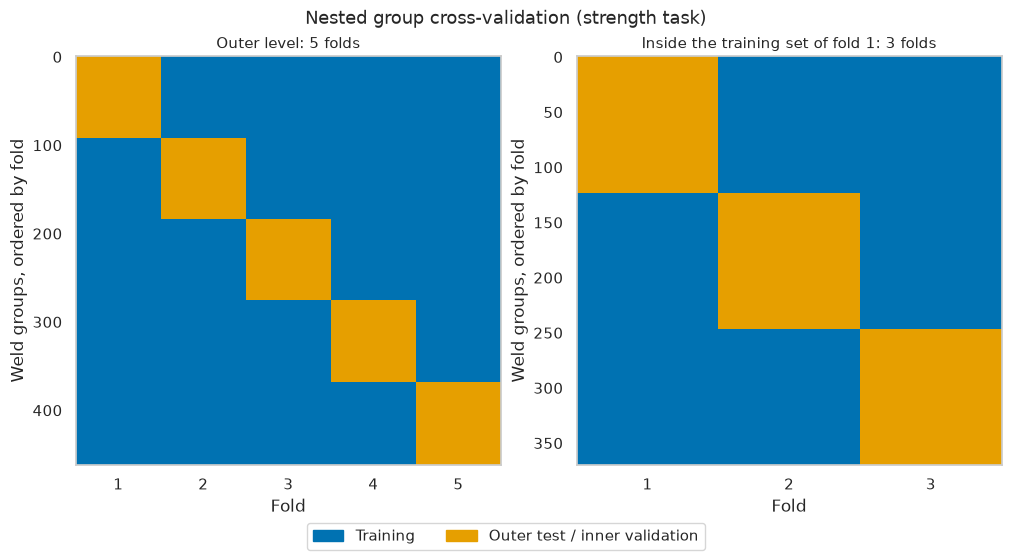

In [28]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# One line of the figure is one weld group
outer_group_fold = {}
for fold, (_, te) in enumerate(outer_splits):
    for group in np.unique(G_strength[te]):
        outer_group_fold[group] = fold
ordered_groups = sorted(outer_group_fold, key=lambda g: (outer_group_fold[g], g))
outer_matrix = np.zeros((len(ordered_groups), 5), dtype=int)
for i, group in enumerate(ordered_groups):
    outer_matrix[i, outer_group_fold[group]] = 1

train_first, _ = outer_splits[0]
g_inner = G_strength[train_first]
inner_splits = list(GroupKFold(3).split(X_strength.iloc[train_first], Y_strength[train_first], g_inner))
inner_group_fold = {}
for fold, (_, va) in enumerate(inner_splits):
    for group in np.unique(g_inner[va]):
        inner_group_fold[group] = fold
inner_order = sorted(inner_group_fold, key=lambda g: (inner_group_fold[g], g))
inner_matrix = np.zeros((len(inner_order), 3), dtype=int)
for i, group in enumerate(inner_order):
    inner_matrix[i, inner_group_fold[group]] = 1

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), layout="constrained")
colors = ListedColormap([BLUE, ORANGE])
for ax, matrix, title in [(axes[0], outer_matrix, "Outer level: 5 folds"),
                          (axes[1], inner_matrix, "Inside the training set of fold 1: 3 folds")]:
    ax.imshow(matrix, cmap=colors, aspect="auto", interpolation="nearest", vmin=0, vmax=1)
    ax.set_xticks(range(matrix.shape[1]), range(1, matrix.shape[1] + 1))
    ax.grid(False)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Weld groups, ordered by fold")
    ax.set_title(title, fontsize=11)
fig.legend(handles=[mpatches.Patch(color=BLUE, label="Training"),
                    mpatches.Patch(color=ORANGE, label="Outer test / inner validation")],
           loc="outside lower center", ncol=2)
fig.suptitle("Nested group cross-validation (strength task)", fontsize=13)
plt.show()

### 5.4 Choice of the semi-supervised method

The lecture CM8 presents, among others, pseudo-labelling and graph-based methods. The literature we rely on is the manifold regularisation of **Belkin et al. (2006)** [B1], the harmonic functions on graphs of **Zhu et al. (2003)** [B2] and the survey of **van Engelen and Hoos (2020)** [B3]. The full references are at the end of the notebook.

We choose a graph-regularised regression because the targets are continuous. Pseudo-labelling would require a confidence measure for values in MPa or %, whereas `SelfTrainingClassifier` and `LabelSpreading` are designed for classes.

The idea is to penalise very different predictions for welds that are close in the input space. The unlabeled rows contribute to this neighbourhood structure. The distance, however, depends on the categories, on the missing indicators and on the distribution of the alloying elements: welds that are close numerically are not necessarily close metallurgically. We therefore compute control models, to separate the effect of the regularisation from the effect of the unlabeled data.

### 5.5 Graph-regularised regression

The preprocessing is fitted on the labeled training rows, then applied to these rows and to the eligible unlabeled inputs. A Nyström map of an RBF kernel, also fitted on the labeled rows only, gives a representation of rank at most 80, with γ = 1/d. The graph connects the ten nearest neighbours in the preprocessed space.

The edge weights are exp(−distance²/(2σ²)), where σ is the median of the non-zero distances. The graph is symmetrised with the maximum of the two directions and has a zero diagonal. We use the Laplacian $L=(D-W)/\bar d$, scaled by the mean degree; it is not the symmetric normalised Laplacian.

With Φ the map centred on the training rows, Y the standardised and centred targets, ℓ the number of labeled rows and n the number of nodes, we minimise:

$$J(B)=\frac{1}{\ell}\|\Phi_LB-Y\|_F^2+\alpha\|B\|_F^2+\frac{\lambda}{n}\operatorname{tr}(B^\top\Phi^\top L\Phi B).$$

The last term penalises variations of the predictions between neighbours. The coefficients are the solution of:

$$\left(\frac{\Phi_L^\top\Phi_L}{\ell}+\alpha I+\frac{\lambda}{n}\Phi^\top L\Phi\right)B=\frac{\Phi_L^\top Y}{\ell}.$$

Since α > 0, the system is positive definite. The intercept is the mean of the training targets; it does not change the differences along the graph. A new weld is predicted with the map and the learned coefficients, without being added to the graph (inductive setting).

The inner grids are α ∈ {10⁻⁵, 10⁻⁴, 10⁻³, 10⁻², 10⁻¹} and λ ∈ {0.01, 0.1, 1}. The α grid goes down to 10⁻⁵: with a grid starting at 10⁻³, the smallest value was selected in every fold, and a value selected on the edge of the grid means that the optimum may lie outside it. The rank, γ and the number of neighbours are fixed. This implementation follows the principle of Belkin et al. in a finite-dimensional approximation; it does not exactly reproduce LapRLS in a full RKHS.

We compute three variants on the same folds:

- `Nystroem_Ridge_control`: λ = 0, no unlabeled data (a supervised kernel ridge regression);
- `Graph_labeled_only`: graph built on the labeled training rows only;
- `Graph_semi_supervised`: graph built with the eligible unlabeled inputs as well.

Each variant tunes its own parameters in the inner folds. With λ = 0, adding unlabeled inputs changes neither the map nor the model.

In [29]:
"""Graph-regularised regression with a Nystroem representation.

The model follows the manifold regularisation principle of Belkin et al. (2006), in a
finite-dimensional approximation. Only the training rows and the eligible unlabeled
inputs are nodes of the graph.
"""
from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.csgraph import connected_components
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.kernel_approximation import Nystroem
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.validation import check_is_fitted


class GraphRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, alpha=0.01, graph_lambda=0.1, n_neighbors=10, n_components=80, random_state=42):
        self.alpha = alpha
        self.graph_lambda = graph_lambda
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y, X_unlabeled=None):
        X, y = np.asarray(X, float), np.asarray(y, float)
        if y.ndim == 1:
            y = y[:, None]
        if not np.isfinite(X).all() or not np.isfinite(y).all():
            raise ValueError("Non-finite inputs")
        # With lambda = 0 the unlabeled rows play no role in the model
        U = (np.empty((0, X.shape[1])) if X_unlabeled is None or self.graph_lambda == 0
             else np.asarray(X_unlabeled, float))
        self.n_labeled_, self.n_unlabeled_ = len(X), len(U)
        self.map_ = Nystroem(kernel="rbf", gamma=1 / X.shape[1], n_components=min(self.n_components, len(X)),
                             random_state=self.random_state).fit(X)
        raw = self.map_.transform(X)
        self.feature_mean_ = raw.mean(axis=0)
        phi = raw - self.feature_mean_
        # The intercept is the mean of the labeled targets; a constant does not change the graph differences
        self.target_mean_ = y.mean(axis=0)
        centered_y = y - self.target_mean_
        G = np.zeros((phi.shape[1], phi.shape[1]))
        self.graph_info_ = {"n_nodes": len(X), "n_edges": 0, "n_components": 0,
                            "components_without_label": 0, "penalty_norm": 0.0}
        if self.graph_lambda > 0:
            all_x = np.vstack([X, U])
            all_phi = self.map_.transform(all_x) - self.feature_mean_
            k = min(self.n_neighbors, len(all_x) - 1)
            distances, indices = NearestNeighbors(n_neighbors=k + 1).fit(all_x).kneighbors(all_x)
            # Remove each point from its own neighbours (with duplicates it is not always in first position)
            rr, cc, dd = [], [], []
            for i in range(len(all_x)):
                keep = indices[i] != i
                ids, ds = indices[i][keep][:k], distances[i][keep][:k]
                rr.extend([i] * len(ids)); cc.extend(ids); dd.extend(ds)
            dd = np.asarray(dd)
            positive = dd[dd > 0]
            sigma = float(np.median(positive)) if len(positive) else 1.0
            weights = np.exp(-dd ** 2 / (2 * sigma ** 2))
            W = sparse.csr_matrix((weights, (rr, cc)), shape=(len(all_x), len(all_x)))
            W = W.maximum(W.T)
            W.setdiag(0); W.eliminate_zeros()
            degree = np.asarray(W.sum(axis=1)).ravel()
            # Scaling by the mean degree makes the penalty comparable between graphs (this is not L_sym)
            lap = (sparse.diags(degree) - W) / max(degree.mean(), 1e-12)
            G = all_phi.T @ (lap @ all_phi) / len(all_x)
            G = (G + G.T) / 2
            n_components, component = connected_components(W, directed=False)
            anchored = set(component[:len(X)])
            self.graph_info_ = {"n_nodes": len(all_x), "n_edges": W.nnz // 2, "n_components": n_components,
                                "components_without_label": n_components - len(anchored),
                                "sigma": sigma, "penalty_norm": float(np.linalg.norm(G))}
        self.graph_penalty_ = G
        A = phi.T @ phi / len(X) + self.alpha * np.eye(phi.shape[1]) + self.graph_lambda * G
        rhs = phi.T @ centered_y / len(X)
        self.coef_ = solve(A, rhs, assume_a="pos")
        self.normal_equation_residual_ = float(np.linalg.norm(A @ self.coef_ - rhs))
        return self

    def predict(self, X):
        check_is_fitted(self, "coef_")
        return (self.map_.transform(np.asarray(X, float)) - self.feature_mean_) @ self.coef_ + self.target_mean_

In [30]:
# Example on the training rows of the first outer fold (illustration only, not a score)
tr, te = outer_splits[0]
held_out_groups = set(G_strength[te])
pool_ids = np.asarray(strength_spec["unlabeled"])
u_ids = np.asarray([i for i in pool_ids if df_ml.loc[i, "Validation_Group"] not in held_out_groups])
assert set(df_ml.loc[u_ids, "Validation_Group"]).isdisjoint(held_out_groups)
pp_demo = make_preprocessor(features_ml)
Z_L_demo = pp_demo.fit_transform(X_strength.iloc[tr]).to_numpy()
Z_U_demo = pp_demo.transform(df_ml.loc[u_ids, features_ml]).to_numpy()
target_scaler_demo = StandardScaler().fit(Y_strength[tr])
graph_demo = GraphRegressor(alpha=0.01, graph_lambda=0.1).fit(
    Z_L_demo, target_scaler_demo.transform(Y_strength[tr]), X_unlabeled=Z_U_demo)
print("Illustrative parameters (not selected): alpha=0.01, lambda=0.1")
print("Labeled rows:", graph_demo.n_labeled_, "- eligible unlabeled rows:", graph_demo.n_unlabeled_)
print("Residual of the linear system:", graph_demo.normal_equation_residual_)
display(pd.DataFrame([graph_demo.graph_info_]))
assert graph_demo.normal_equation_residual_ < 1e-6

Illustrative parameters (not selected): alpha=0.01, lambda=0.1
Labeled rows: 532 - eligible unlabeled rows: 879
Residual of the linear system: 6.963609462303308e-17


,n_nodes,n_edges,n_components,components_without_label,sigma,penalty_norm
0,1411,8972,16,4,1.46688,0.002981


The audit counts the connected components of the graph that contain no labeled row. The model still produces a prediction there, but without a local measurement to support it. The indices of the unlabeled rows are recorded after the exclusion of the validation and test groups.

### 5.6 Charpy energy

The Charpy test temperature is a known condition of the test and is used as a feature. The main experiment keeps the 100 J and 28 J values: the [MAP documentation](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html) does not flag them as default values, so removing them would be an unverified correction of the data.

A sensitivity analysis (`charpy_without_100`) removes the 100 J values, without turning them into unlabeled rows. It keeps **523 rows in 200 groups**, instead of 879 rows in 328 groups. All the supervised models are evaluated with the same 5 × 3 protocol. The 28 J values are kept. Since this analysis changes the population and the folds, its scores are not directly comparable with those of the main experiment: it tells whether the ranking of the models and the order of magnitude of the errors survive the removal of the suspicious values.

In [31]:
"""Nested group cross-validation, raw results and audit of the exclusions."""
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

N_OUTER, N_INNER = 5, 3
GRAPH_ALPHAS = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
GRAPH_LAMBDAS = [0.01, 0.1, 1.0]
# Any change of this description invalidates the results saved on disk
PROTOCOL = {"version": 2, "outer_folds": N_OUTER, "inner_folds": N_INNER, "seed": SEED,
            "group_column": "Validation_Group",
            "grids": {name: grid for name, (_, grid) in supervised_specs().items()},
            "graph_alphas": GRAPH_ALPHAS, "graph_lambdas": GRAPH_LAMBDAS}
RESULT_FILES = ["availability.csv", "fold_assignments.csv", "metrics_by_fold.csv", "oof_predictions.csv",
                "inner_search.csv", "selected_parameters.csv", "semi_supervised_audit.csv", "warnings.csv",
                "metrics_oof_pooled.csv"]


def group_weights(groups):
    s = pd.Series(np.asarray(groups))
    return 1 / s.map(s.value_counts()).to_numpy()


def tuning_loss(y, pred, train_scale, groups):
    # Each target contributes its RMSE divided by its training standard deviation
    mse = np.average(((np.asarray(y) - pred) / train_scale) ** 2, axis=0, weights=group_weights(groups))
    return float(np.sqrt(mse).mean())


def raw_metrics(y, pred, groups, targets):
    records = []
    for weighting, weights in [("rows", None), ("groups", group_weights(groups))]:
        for j, target in enumerate(targets):
            records.append({"target": target, "weighting": weighting,
                            "RMSE": float(np.sqrt(mean_squared_error(y[:, j], pred[:, j], sample_weight=weights))),
                            "MAE": float(mean_absolute_error(y[:, j], pred[:, j], sample_weight=weights)),
                            "R2": float(r2_score(y[:, j], pred[:, j], sample_weight=weights))})
    return records


def record(task, model, fold, ids, y, pred, groups, targets, metrics, predictions):
    assert np.isfinite(pred).all()
    for r in raw_metrics(y, pred, groups, targets):
        metrics.append({"task": task, "model": model, "outer_fold": fold, **r})
    for i, row_id in enumerate(ids):
        for j, target in enumerate(targets):
            predictions.append({"task": task, "model": model, "outer_fold": fold, "row_id": int(row_id),
                                "group": int(groups[i]), "target": target,
                                "y_true": float(y[i, j]), "y_pred": float(pred[i, j])})


def pooled(d):
    w = group_weights(d.group)
    return pd.Series({"n": len(d), "RMSE_rows": np.sqrt(np.mean((d.y_true - d.y_pred) ** 2)),
                      "MAE_rows": np.mean(np.abs(d.y_true - d.y_pred)),
                      "R2_rows": r2_score(d.y_true, d.y_pred),
                      "RMSE_groups": np.sqrt(np.average((d.y_true - d.y_pred) ** 2, weights=w)),
                      "MAE_groups": np.average(np.abs(d.y_true - d.y_pred), weights=w),
                      "R2_groups": r2_score(d.y_true, d.y_pred, sample_weight=w),
                      "bias_groups": np.average(d.y_pred - d.y_true, weights=w)})


def run_graph_models(data, spec, X, y, ids, groups, train, test, inner, outer_number, out):
    """Three graph variants for one outer fold of the strength task."""
    searches, selected, audits, metrics, predictions = out
    test_groups, train_groups = set(groups[test]), set(groups[train])
    # Pool: 840 rows without targets and 147 rows with partial targets (their known targets are not used)
    pool_ids = np.asarray(spec["unlabeled"])

    def eligible(allowed_groups, mode):
        if mode != "Graph_semi_supervised":
            return np.asarray([], dtype=int)
        banned = set(groups) - allowed_groups
        return np.asarray([i for i in pool_ids if int(data.loc[i, "Validation_Group"]) not in banned])

    for mode in ["Nystroem_Ridge_control", "Graph_labeled_only", "Graph_semi_supervised"]:
        began = time.perf_counter()
        lambdas = [0.0] if mode == "Nystroem_Ridge_control" else GRAPH_LAMBDAS
        configurations = list(ParameterGrid({"alpha": GRAPH_ALPHAS, "graph_lambda": lambdas}))
        # The fold-specific transformations are computed once; each candidate then builds its own graph
        fold_data = []
        for inner_number, (itrain, ival) in enumerate(inner, 1):
            a, b = train[itrain], train[ival]
            uids = eligible(set(groups[a]), mode)
            assert set(data.loc[uids, "Validation_Group"]).isdisjoint(set(groups[b]) | test_groups)
            pp = make_preprocessor(spec["features"])
            z = pp.fit_transform(X.iloc[a]).to_numpy()
            zv = pp.transform(X.iloc[b]).to_numpy()
            zu = pp.transform(data.loc[uids, spec["features"]]).to_numpy() if len(uids) else None
            ts = StandardScaler().fit(y[a])
            fold_data.append((z, zv, zu, ts, ts.transform(y[a]), y[b], groups[b]))
            audits.append({"task": "strength", "model": mode, "outer_fold": outer_number,
                           "inner_fold": inner_number, "n_labeled_train": len(a), "n_unlabeled": len(uids),
                           "n_validation": len(b), "train_row_ids": json.dumps(ids[a].tolist()),
                           "validation_row_ids": json.dumps(ids[b].tolist()),
                           "unlabeled_row_ids": json.dumps(uids.tolist())})
        losses = []
        for config in configurations:
            split_losses = []
            for z, zv, zu, ts, ys, yv, gv in fold_data:
                est = GraphRegressor(**config).fit(z, ys, X_unlabeled=zu)
                split_losses.append(tuning_loss(yv, ts.inverse_transform(est.predict(zv)), ts.scale_, gv))
            losses.append(float(np.mean(split_losses)))
            searches.append({"task": "strength", "outer_fold": outer_number, "model": mode,
                             "parameters": json.dumps(config, sort_keys=True), "inner_loss_mean": losses[-1],
                             "inner_losses": json.dumps(split_losses)})
        best = configurations[int(np.argmin(losses))]
        uids = eligible(train_groups, mode)
        assert set(data.loc[uids, "Validation_Group"]).isdisjoint(test_groups)
        pp = make_preprocessor(spec["features"])
        z = pp.fit_transform(X.iloc[train]).to_numpy()
        zt = pp.transform(X.iloc[test]).to_numpy()
        zu = pp.transform(data.loc[uids, spec["features"]]).to_numpy() if len(uids) else None
        ts = StandardScaler().fit(y[train])
        est = GraphRegressor(**best).fit(z, ts.transform(y[train]), X_unlabeled=zu)
        pred = ts.inverse_transform(est.predict(zt))
        assert est.normal_equation_residual_ < 1e-6
        if mode == "Graph_semi_supervised":
            assert est.n_unlabeled_ > 0
        audits.append({"task": "strength", "model": mode, "outer_fold": outer_number, "inner_fold": 0,
                       "n_labeled_train": len(train), "n_unlabeled": len(uids), "n_validation": len(test),
                       "train_row_ids": json.dumps(ids[train].tolist()),
                       "validation_row_ids": json.dumps(ids[test].tolist()),
                       "unlabeled_row_ids": json.dumps(uids.tolist()), **est.graph_info_})
        selected.append({"task": "strength", "outer_fold": outer_number, "model": mode,
                         "parameters": json.dumps(best, sort_keys=True),
                         "search_and_refit_seconds": time.perf_counter() - began,
                         "n_train": len(train), "n_test": len(test)})
        record("strength", mode, outer_number, ids[test], y[test], pred, groups[test], STRENGTH, metrics, predictions)
        print(f"  fold {outer_number}/{N_OUTER} {mode}: done, U={len(uids)}", flush=True)


def run_experiments():
    data = load_ml_data()
    specs = tasks(data, list(features))
    folds, metrics, predictions, searches, audits, selected, warning_log = [], [], [], [], [], [], []
    start = time.perf_counter()
    for task_name, spec in specs.items():
        ids, targets = np.asarray(spec["labeled"]), spec["targets"]
        X = data.loc[ids, spec["features"]]
        y = data.loc[ids, targets].to_numpy(float)
        groups = data.loc[ids, "Validation_Group"].to_numpy()
        candidates = supervised_specs()
        outer = list(GroupKFold(n_splits=N_OUTER).split(X, y, groups))
        print(f"{task_name}: {len(ids)} rows, {len(np.unique(groups))} groups", flush=True)
        for outer_number, (train, test) in enumerate(outer, 1):
            assert set(groups[train]).isdisjoint(set(groups[test]))
            inner = list(GroupKFold(n_splits=N_INNER).split(X.iloc[train], y[train], groups[train]))
            folds += [{"task": task_name, "row_id": int(ids[i]), "group": int(groups[i]),
                       "outer_fold": outer_number} for i in test]
            for model_name, (base, grid) in candidates.items():
                began = time.perf_counter()
                config_list = list(ParameterGrid(grid))
                losses = []
                for config in config_list:
                    split_losses = []
                    for itrain, ival in inner:
                        a, b = train[itrain], train[ival]
                        assert set(groups[a]).isdisjoint(set(groups[b]))
                        model = pipeline(make_preprocessor(spec["features"]), clone(base).set_params(**config))
                        with warnings.catch_warnings(record=True) as ws:
                            warnings.simplefilter("always")
                            model.fit(X.iloc[a], fit_target(y[a], model_name))
                        warning_log += [{"task": task_name, "fold": outer_number, "model": model_name,
                                         "message": str(w.message)} for w in ws]
                        pred = np.asarray(model.predict(X.iloc[b])).reshape(len(b), len(targets))
                        scale = model.named_steps["regression"].transformer_.scale_
                        split_losses.append(tuning_loss(y[b], pred, scale, groups[b]))
                    losses.append(float(np.mean(split_losses)))
                    searches.append({"task": task_name, "outer_fold": outer_number, "model": model_name,
                                     "parameters": json.dumps(config, sort_keys=True),
                                     "inner_loss_mean": losses[-1], "inner_losses": json.dumps(split_losses)})
                best = config_list[int(np.argmin(losses))]
                final = pipeline(make_preprocessor(spec["features"]), clone(base).set_params(**best))
                final.fit(X.iloc[train], fit_target(y[train], model_name))
                pred = np.asarray(final.predict(X.iloc[test])).reshape(len(test), len(targets))
                selected.append({"task": task_name, "outer_fold": outer_number, "model": model_name,
                                 "parameters": json.dumps(best, sort_keys=True),
                                 "search_and_refit_seconds": time.perf_counter() - began,
                                 "n_train": len(train), "n_test": len(test)})
                record(task_name, model_name, outer_number, ids[test], y[test], pred, groups[test], targets,
                       metrics, predictions)
            print(f"  fold {outer_number}/{N_OUTER}: supervised models done", flush=True)
            if task_name == "strength":
                run_graph_models(data, spec, X, y, ids, groups, train, test, inner, outer_number,
                                 (searches, selected, audits, metrics, predictions))
    tables = {
        "availability.csv": availability(data, specs),
        "fold_assignments.csv": pd.DataFrame(folds), "metrics_by_fold.csv": pd.DataFrame(metrics),
        "oof_predictions.csv": pd.DataFrame(predictions), "inner_search.csv": pd.DataFrame(searches),
        "selected_parameters.csv": pd.DataFrame(selected), "semi_supervised_audit.csv": pd.DataFrame(audits),
        "warnings.csv": pd.DataFrame(warning_log, columns=["task", "fold", "model", "message"]),
    }
    tables["metrics_oof_pooled.csv"] = (tables["oof_predictions.csv"].groupby(["task", "model", "target"])
                                        .apply(pooled, include_groups=False).reset_index())
    metadata = {"status": "complete", "protocol": PROTOCOL, "python": platform.python_version(),
                "numpy": np.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                "total_seconds": time.perf_counter() - start}
    RESULTS_DIR.mkdir(exist_ok=True)
    for name, table in tables.items():
        table.to_csv(RESULTS_DIR / name, index=False)
    (RESULTS_DIR / "run_metadata.json").write_text(json.dumps(metadata, indent=2))
    print(f"FINISHED in {metadata['total_seconds']:.0f} s", flush=True)


def load_results():
    """Results saved on disk, or None if they are missing or were produced by another protocol."""
    meta_path = RESULTS_DIR / "run_metadata.json"
    if not meta_path.is_file():
        return None
    metadata = json.loads(meta_path.read_text())
    if metadata.get("status") != "complete" or metadata.get("protocol") != json.loads(json.dumps(PROTOCOL)):
        return None
    if not all((RESULTS_DIR / name).is_file() for name in RESULT_FILES):
        return None
    results = {name: pd.read_csv(RESULTS_DIR / name) for name in RESULT_FILES}
    results["run_metadata.json"] = metadata
    return results

### 5.7 Running the experiments

The full computation (three tasks, 5 × 3 folds, nine supervised models and three graph variants) takes a few minutes. Its outputs are saved as CSV files in `results/`, together with a description of the protocol. The next cell reloads them when they exist and were produced by the same protocol; otherwise (or if `RECOMPUTE = True`) it reruns the experiments.

`inner_search.csv` contains every hyperparameter configuration tried and its inner error; `selected_parameters.csv` gives the configuration retained in each outer fold. The outer scores were not used to modify the grids, and no final model is chosen in this phase.

In [32]:
RECOMPUTE = False
results_ml = None if RECOMPUTE else load_results()
if results_ml is None:
    run_experiments()
    results_ml = load_results()
assert results_ml is not None

metadata = results_ml["run_metadata.json"]
print(f"Results of the complete {N_OUTER} x {N_INNER} run, computed in {metadata['total_seconds']:.0f} s "
      f"(Python {metadata['python']}, scikit-learn {metadata['scikit_learn']}).")

oof = results_ml["oof_predictions.csv"]
folds = results_ml["fold_assignments.csv"]
metrics_raw = results_ml["metrics_by_fold.csv"]
audit = results_ml["semi_supervised_audit.csv"]
selected = results_ml["selected_parameters.csv"]
display(oof.groupby(["task", "model"]).agg(rows=("row_id", "nunique"), targets=("target", "nunique"),
                                             folds=("outer_fold", "nunique")).reset_index())

Results of the complete 5 x 3 run, computed in 242 s (Python 3.12.3, scikit-learn 1.9.1).


,task,model,rows,targets,folds
0,charpy,Bagging,879,1,5
1,charpy,DecisionTree,879,1,5
2,charpy,Dummy_mean,879,1,5
3,charpy,ExtraTrees,879,1,5
4,charpy,KNN,879,1,5
5,charpy,OLS,879,1,5
6,charpy,RandomForest,879,1,5
7,charpy,Ridge,879,1,5
8,charpy,SVR_RBF,879,1,5
9,charpy_without_100,Bagging,523,1,5


### Output files

`oof_predictions.csv` contains the observed and predicted values, with one line per target, model and test. `metrics_by_fold.csv` gives MAE, RMSE and R² separately for each target and fold, with weights per row (`rows`) or per group (`groups`). `metrics_oof_pooled.csv` computes the scores on all the OOF predictions together: they may differ from the mean of the five fold scores. The five folds are not independent repetitions, so their dispersion alone is not a confidence interval (see section 6.3).

In [33]:
# Selected configuration in each fold, and structure of the semi-supervised graphs
selection_summary = (selected.groupby(["task", "model"])["parameters"]
                     .agg(lambda s: "; ".join(f"{p} x{n}" for p, n in s.value_counts().items())))
display(selection_summary.to_frame("selected configurations (x number of folds)"))
display(audit.loc[audit.inner_fold.eq(0) & audit.model.eq("Graph_semi_supervised"),
                  ["outer_fold", "n_labeled_train", "n_unlabeled", "n_nodes", "n_edges",
                   "n_components", "components_without_label"]])

selected configurations (x number of folds)
task               model                                                                    
charpy             Bagging                 {"estimator__max_depth": null, "max_samples": ...
                   DecisionTree            {"max_depth": null, "min_samples_leaf": 8} x3;...
                   Dummy_mean                                                          {} x5
                   ExtraTrees              {"max_features": 0.5, "min_samples_leaf": 2} x...
                   KNN                          {"n_neighbors": 3, "weights": "distance"} x5
                   OLS                                                                 {} x5
                   RandomForest              {"max_features": 0.5, "min_samples_leaf": 2} x5
                   Ridge                                {"alpha": 100} x4; {"alpha": 0.1} x1
                   SVR_RBF                 {"estimator__C": 10, "estimator__epsilon": 0.0...
charpy_without_100 Bagging                 {"estimator__max_depth": null, "max_samples": ...
                   DecisionTree            {"max_depth": null, "min_samples_leaf": 2} x2;...
                   Dummy_mean                                                          {} x5
                   ExtraTrees                {"max_features": 0.5, "min_samples_leaf": 2} x5
                   KNN                          {"n_neighbors": 3, "weights": "distance"} x5
                   OLS                                                                 {} x5
                   RandomForest              {"max_features": 0.5, "min_samples_leaf": 2} x5
                   Ridge                                 {"alpha": 10} x3; {"alpha": 100} x2
                   SVR_RBF                 {"estimator__C": 100, "estimator__epsilon": 0....
strength           Bagging                 {"estimator__max_depth": null, "max_samples": ...
                   DecisionTree            {"max_depth": null, "min_samples_leaf": 2} x4;...
                   Dummy_mean                                                          {} x5
                   ExtraTrees                {"max_features": 1.0, "min_samples_leaf": 2} x5
                   Graph_labeled_only      {"alpha": 0.0001, "graph_lambda": 0.01} x2; {"...
                   Graph_semi_supervised   {"alpha": 0.0001, "graph_lambda": 0.01} x2; {"...
                   KNN                          {"n_neighbors": 3, "weights": "distance"} x5
                   Nystroem_Ridge_control  {"alpha": 0.0001, "graph_lambda": 0.0} x3; {"a...
                   OLS                                                                 {} x5
                   RandomForest            {"max_features": 0.5, "min_samples_leaf": 2} x...
                   Ridge                                 {"alpha": 10} x3; {"alpha": 100} x2
                   SVR_RBF                 {"estimator__C": 10, "estimator__epsilon": 0.2...

,outer_fold,n_labeled_train,n_unlabeled,n_nodes,n_edges,n_components,components_without_label
11,1,532,879,1411.0,8972.0,16.0,4.0
23,2,532,873,1405.0,8783.0,19.0,6.0
35,3,532,848,1380.0,8748.0,14.0,5.0
47,4,532,817,1349.0,8524.0,16.0,4.0
59,5,532,868,1400.0,8863.0,16.0,4.0


### 5.8 Checks of the predictions and of the folds

We check that there is exactly one prediction for each row, target and model, and that all the expected rows are present. We also check that each group and each `Weld_ID` stays in a single outer fold, and, from the indices saved in the audit, that the unlabeled pool never contains a validation or test group.

In [34]:
assert not oof.duplicated(["task", "model", "row_id", "target"]).any()
assert np.isfinite(oof[["y_true", "y_pred"]].to_numpy()).all()
for task, assigned in folds.groupby("task"):
    assert assigned.groupby("group").outer_fold.nunique().eq(1).all()
    joined = assigned.merge(df_ml[["Weld_ID"]], left_on="row_id", right_index=True)
    assert joined.groupby("Weld_ID").outer_fold.nunique().eq(1).all()
    for (model, target), predictions in oof[oof.task.eq(task)].groupby(["model", "target"]):
        assert set(predictions.row_id) == set(assigned.row_id)
        assert set(predictions.outer_fold) == set(range(1, N_OUTER + 1))
        np.testing.assert_allclose(predictions.y_true.to_numpy(), df_ml.loc[predictions.row_id, target].to_numpy(float))
for _, rec in audit.iterrows():
    tr_ids, va_ids, un_ids = (json.loads(rec[c]) for c in ["train_row_ids", "validation_row_ids", "unlabeled_row_ids"])
    gt, gv, gu = [set(df_ml.loc[i, "Validation_Group"]) for i in [tr_ids, va_ids, un_ids]]
    assert gt.isdisjoint(gv) and gu.isdisjoint(gv)
    outer_test_ids = folds.loc[folds.task.eq("strength") & folds.outer_fold.eq(rec.outer_fold), "row_id"]
    assert gu.isdisjoint(set(df_ml.loc[outer_test_ids, "Validation_Group"]))
    assert set(un_ids).issubset(set(strength_spec["unlabeled"]))
print("Checks passed: complete OOF predictions, groups and Weld_ID separated, unlabeled pool without test or validation rows.")

Checks passed: complete OOF predictions, groups and Weld_ID separated, unlabeled pool without test or validation rows.


### 5.9 Tests of the graph regressor

The numerical test recovers the Ridge equations in the Nyström map when λ = 0; in that case adding unlabeled inputs does not change the result. With λ > 0, the unlabeled inputs do change the penalty and the predictions.

In [35]:
rng_test = np.random.default_rng(25)
x_test = rng_test.normal(size=(32, 4))
y_test = np.column_stack([x_test[:, 0] ** 2, x_test[:, 1] + x_test[:, 0]])
u_test = rng_test.normal(size=(60, 4)) + 0.5
ridge_test = GraphRegressor(graph_lambda=0, n_components=20).fit(x_test, y_test)
zero_test = GraphRegressor(graph_lambda=0, n_components=20).fit(x_test, y_test, u_test)
np.testing.assert_allclose(ridge_test.predict(x_test), zero_test.predict(x_test), atol=1e-12)
phi_test = ridge_test.map_.transform(x_test) - ridge_test.feature_mean_
expected_test = np.linalg.solve(phi_test.T @ phi_test / len(x_test) + ridge_test.alpha * np.eye(phi_test.shape[1]),
                                phi_test.T @ (y_test - y_test.mean(axis=0)) / len(x_test))
np.testing.assert_allclose(ridge_test.coef_, expected_test, atol=1e-10)
label_test = GraphRegressor(graph_lambda=0.5, n_components=20).fit(x_test, y_test)
semi_test = GraphRegressor(graph_lambda=0.5, n_components=20).fit(x_test, y_test, u_test)
assert np.linalg.norm(semi_test.graph_penalty_ - label_test.graph_penalty_) > 1e-4
assert np.linalg.norm(semi_test.predict(x_test) - label_test.predict(x_test)) > 1e-4
assert semi_test.normal_equation_residual_ < 1e-9
print("Tests passed: Ridge solution recovered and unlabeled inputs effectively used.")

Tests passed: Ridge solution recovered and unlabeled inputs effectively used.


## Phase 6: Comparative analysis, conclusion and recommendations

This phase answers the three questions of the project:

1. **Comparative analysis** of the performance of the models and methods of Phase 5, with a justified choice of metrics (6.1 to 6.6);
2. **Conclusion** on the most appropriate approach to predict weld quality (6.7);
3. **Recommendations** to obtain a good weld quality, drawn from the interpretation of the selected models (6.8 and 6.9).

Every score below is computed on the out-of-fold predictions of Phase 5: no prediction comes from a model that saw the weld group it predicts.

### 6.1 Choice of the metrics

The targets are continuous physical quantities, so we use regression metrics. Each one answers a different question:

| Metric | Unit | Why it is relevant here |
|---|---|---|
| **RMSE** | MPa, %, J | Error in the unit of the specification. It penalises large errors strongly, which matters for a quality decision: a large over-estimation of the toughness or of the strength of a weld is the dangerous case. **Main metric.** |
| **MAE** | MPa, %, J | Typical error, less sensitive to a few extreme welds. The ratio RMSE / MAE shows whether the errors have heavy tails. |
| **R²** | none | Fraction of the variance explained, relative to a model that always predicts the mean (R² = 0). It compares targets of different units and different spread. |
| **Normalised RMSE** = RMSE / standard deviation of the target = √(1 − R²) | none | Used to **rank** the models: it is averaged over the three strength targets, which is the criterion used to tune the hyperparameters in Phase 5 (selection and evaluation use the same objective). |
| **Bias** (mean of prediction − observation) | MPa, %, J | Detects a systematic over- or under-estimation. |

Three choices complete the metrics:

- **Weighting by weld group.** Several rows are tests of the same weld (different test temperatures, repeated tests). Weighting each row by 1 / (size of its group) gives the same weight to each weld, so the scores estimate the error on a **new weld**, which is the practical use of the model. The row-weighted scores are also saved; the conclusions do not change with them.
- **Pooled OOF scores** (all the test folds together) are used for the ranking; the dispersion between the five folds shows the stability of the models.
- **Uncertainty of the differences.** Two models are compared with a paired bootstrap on the weld groups (section 6.3): the same resampled welds are used for both models, so the interval reflects the difference between models and not the difficulty of the welds.

We do not use classification metrics (accuracy, F1): there is no documented acceptance threshold in the database (the 28 J values may be one, but this is not confirmed, see section 4.2), and converting continuous targets into classes would lose information.

We add two simple baselines, evaluated on exactly the same folds, to check what the models learn beyond the obvious structure of the data:

- `WeldType_mean`: the mean of the training welds of the same weld type (Phase 3 showed that the weld families are separated in the data, so a model could just learn the family);
- `TestTemp_mean` (Charpy only): the mean of the training tests done at the same temperature (the toughness depends strongly on the test temperature).

In [36]:
def simple_baselines():
    """Group means computed on the training rows of each outer fold of Phase 5."""
    rows = []
    keys = {"WeldType_mean": "Type_of_weld", "TestTemp_mean": "Charpy_temp_C"}
    for task, assigned in folds.groupby("task"):
        targets = task_specs[task]["targets"]
        for model, key in keys.items():
            if key == "Charpy_temp_C" and task == "strength":
                continue
            for fold in range(1, N_OUTER + 1):
                test_ids = assigned.loc[assigned.outer_fold.eq(fold), "row_id"].to_numpy()
                train_ids = assigned.loc[assigned.outer_fold.ne(fold), "row_id"].to_numpy()
                train = df_ml.loc[train_ids]
                for target in targets:
                    means = train.groupby(key)[target].mean()
                    pred = df_ml.loc[test_ids, key].map(means).fillna(train[target].mean())
                    rows.append(pd.DataFrame({
                        "task": task, "model": model, "outer_fold": fold, "row_id": test_ids,
                        "group": df_ml.loc[test_ids, "Validation_Group"].to_numpy(), "target": target,
                        "y_true": df_ml.loc[test_ids, target].to_numpy(float), "y_pred": pred.to_numpy(float)}))
    return pd.concat(rows, ignore_index=True)


oof_all = pd.concat([oof, simple_baselines()], ignore_index=True)
pooled_all = oof_all.groupby(["task", "model", "target"]).apply(pooled, include_groups=False).reset_index()
pooled_all["nRMSE_groups"] = np.sqrt(1 - pooled_all["R2_groups"])

BASELINES = ["Dummy_mean", "WeldType_mean", "TestTemp_mean"]
SHORT = {"Yield_strength_MPa": "Yield", "Ultimate_tensile_strength_MPa": "UTS",
         "Elongation_pct": "Elongation", "Charpy_toughness_J": "Charpy"}

ranking = (pooled_all.groupby(["task", "model"])["nRMSE_groups"].mean()
           .rename("mean_nRMSE").reset_index().sort_values(["task", "mean_nRMSE"]))
best_model = {task: d.loc[~d.model.isin(BASELINES), "model"].iloc[0] for task, d in ranking.groupby("task")}
print("Best model of each task (lowest mean normalised RMSE):", best_model)


def score_table(task):
    d = pooled_all[pooled_all.task.eq(task)].copy()
    d["target"] = d["target"].map(SHORT)
    wide = d.pivot(index="model", columns="target", values=["R2_groups", "RMSE_groups", "MAE_groups", "bias_groups"])
    wide.columns = [f"{metric.split('_')[0]} {target}" for metric, target in wide.columns]
    order = ranking[ranking.task.eq(task)].set_index("model")["mean_nRMSE"]
    return wide.join(order).sort_values("mean_nRMSE")[["mean_nRMSE", *wide.columns]].round(3)

Best model of each task (lowest mean normalised RMSE): {'charpy': 'ExtraTrees', 'charpy_without_100': 'ExtraTrees', 'strength': 'SVR_RBF'}


### 6.2 Strength model: comparison of the methods

Scores weighted by weld group, on the 665 welds of the strength task (462 groups). Models are sorted by the mean normalised RMSE over the three targets (lower is better).

In [37]:
display(score_table("strength"))

,mean_nRMSE,R2 Elongation,R2 UTS,R2 Yield,RMSE Elongation,RMSE UTS,RMSE Yield,MAE Elongation,MAE UTS,MAE Yield,bias Elongation,bias UTS,bias Yield
model,,,,,,,,,,,,,
SVR_RBF,0.442,0.737,0.881,0.781,2.578,30.903,38.825,1.927,19.014,25.429,0.072,-1.108,-0.911
ExtraTrees,0.481,0.761,0.814,0.728,2.454,38.662,43.303,1.845,24.814,29.241,0.134,-2.012,-2.156
RandomForest,0.514,0.736,0.783,0.686,2.582,41.768,46.523,1.990,28.628,32.930,0.126,-1.205,-1.143
Bagging,0.515,0.740,0.777,0.682,2.562,42.268,46.835,1.974,28.851,32.853,0.186,-2.267,-2.201
KNN,0.537,0.731,0.762,0.636,2.605,43.688,50.105,1.939,28.088,32.800,0.299,-5.204,-5.238
Graph_labeled_only,0.587,0.637,0.725,0.599,3.027,46.996,52.592,2.310,30.541,35.592,0.139,0.474,-0.221
Graph_semi_supervised,0.588,0.637,0.724,0.597,3.028,47.068,52.694,2.309,30.689,35.708,0.135,0.533,-0.148
Nystroem_Ridge_control,0.588,0.637,0.724,0.596,3.028,47.095,52.763,2.309,30.763,35.768,0.134,0.515,-0.156
OLS,0.638,0.540,0.716,0.506,3.407,47.752,58.344,2.604,34.630,42.938,0.047,-1.005,-0.313


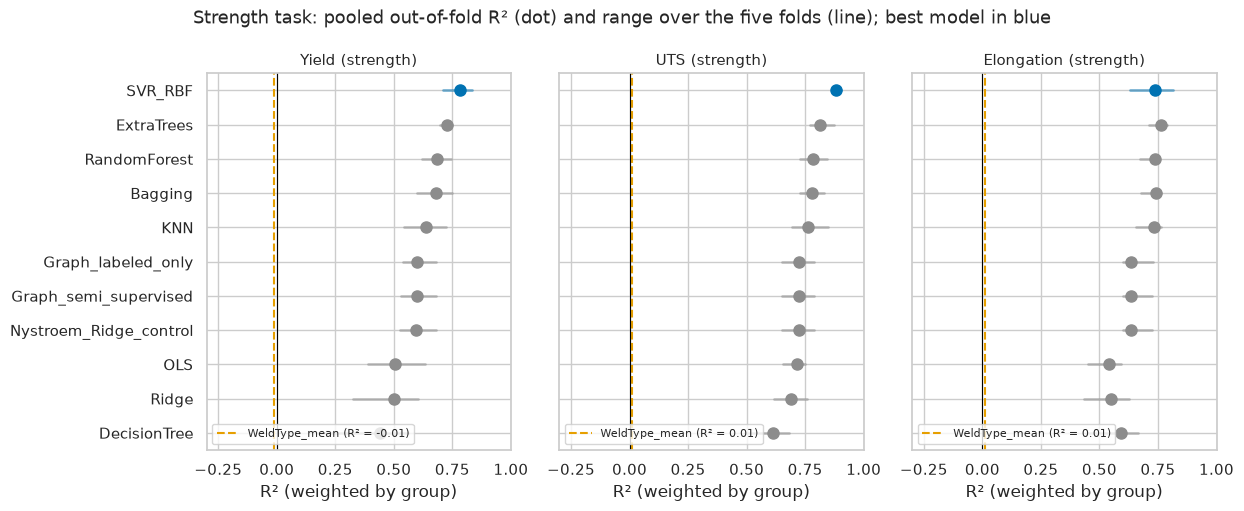

In [38]:
def plot_r2_by_model(task_targets, title):
    """Pooled R2 (dot) and range of the five fold R2 (line), for each model and target."""
    fold_r2 = metrics_raw[metrics_raw.weighting.eq("groups")]
    fig, axes = plt.subplots(1, len(task_targets), figsize=(4.2 * len(task_targets), 5.2), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (task, target) in zip(axes, task_targets):
        models = [m for m in ranking[ranking.task.eq(task)].model if m not in BASELINES][::-1]
        for y_pos, model in enumerate(models):
            per_fold = fold_r2[(fold_r2.task == task) & (fold_r2.model == model) & (fold_r2.target == target)].R2
            r2 = pooled_all.query("task == @task and model == @model and target == @target").R2_groups.iloc[0]
            color = BLUE if model == best_model[task] else GREY
            ax.plot([per_fold.min(), per_fold.max()], [y_pos, y_pos], color=color, alpha=0.5, linewidth=2)
            ax.plot(r2, y_pos, "o", color=color, markersize=8)
        baseline = "WeldType_mean" if task == "strength" else "TestTemp_mean"
        ref = pooled_all.query("task == @task and model == @baseline and target == @target").R2_groups.iloc[0]
        ax.axvline(ref, color=ORANGE, linestyle="--", linewidth=1.5, label=f"{baseline} (R² = {ref:.2f})")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_yticks(range(len(models)), models)
        ax.set_xlim(-0.3, 1)
        ax.set_xlabel("R² (weighted by group)")
        ax.set_title(f"{SHORT[target]} ({task})", fontsize=11)
        ax.legend(loc="lower left", fontsize=8)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_r2_by_model([("strength", t) for t in STRENGTH],
                 "Strength task: pooled out-of-fold R² (dot) and range over the five folds (line); best model in blue")

**Reading of the strength results.**

- All the learned models are far better than the baselines. The **SVR with RBF kernel** has the lowest mean normalised RMSE (0.442): R² = 0.78 for the yield strength (RMSE 39 MPa, MAE 25 MPa), 0.88 for the tensile strength (RMSE 31 MPa, MAE 19 MPa) and 0.74 for the elongation (RMSE 2.6 %, MAE 1.9 %). **ExtraTrees** is second (0.481) and is the best model for the elongation (R² = 0.76, RMSE 2.5 %).
- The models that rely on the neighbourhood of a weld (SVR, KNN) or that average many trees (ExtraTrees, random forest, bagging) beat the linear models (OLS and Ridge, R² between 0.50 and 0.72) and the single decision tree, which is the least accurate and the least stable (R² = 0.44 for the yield strength). The relations between composition and strength are therefore non-linear, as anticipated in section 4.6.
- The weld-type baseline is not better than the global mean (R² ≈ 0): the welding process alone does not predict the strength. The models learn much more than the weld family, mainly from the composition (section 6.8).
- The biases are small compared with the errors (about −1 MPa for the SVR), so there is no systematic over-estimation. The RMSE/MAE ratio of the SVR is between 1.3 and 1.6: a minority of welds have large errors (section 6.6).

### 6.3 Are the differences significant?

The five folds are not independent repetitions, and the welds are grouped. To estimate the uncertainty of a difference between two models, we resample the **weld groups** with replacement (2000 bootstrap samples) and recompute, on each sample, the mean normalised RMSE of both models on the same welds. The table gives the difference with the best model (positive = worse than the best model), its 95% percentile interval, and the fraction of bootstrap samples in which the model is better than the best one.

This bootstrap is conditional on the fitted models: it measures the uncertainty due to the finite set of test welds, not the variability of the training. It is complemented by the fold dispersion of section 6.2.

In [39]:
def bootstrap_against(task, reference, n_boot=2000, seed=SEED):
    d = oof_all[oof_all.task.eq(task)]
    models = sorted(d.model.unique())
    targets = task_specs[task]["targets"]
    group_ids = np.unique(d.group)
    position = {g: i for i, g in enumerate(group_ids)}
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, len(group_ids), size=(n_boot, len(group_ids)))
    counts = np.zeros((n_boot, len(group_ids)))
    np.add.at(counts, (np.repeat(np.arange(n_boot), len(group_ids)), draws.ravel()), 1)
    full = np.ones((1, len(group_ids)))
    total_boot, total_full = 0, 0
    for target in targets:
        wide = d[d.target.eq(target)].pivot(index="row_id", columns="model", values="y_pred")[models]
        info = d[d.target.eq(target)].drop_duplicates("row_id").set_index("row_id").loc[wide.index]
        g_index = info.group.map(position).to_numpy()
        w = group_weights(info.group)
        y = info.y_true.to_numpy()
        # Sums per group: weighted squared errors of each model, and moments of y for the total variance
        sse = np.zeros((len(group_ids), len(models)))
        np.add.at(sse, g_index, (w[:, None] * (wide.to_numpy() - y[:, None]) ** 2))
        moments = np.zeros((len(group_ids), 3))
        np.add.at(moments, g_index, np.column_stack([w, w * y, w * y ** 2]))
        for k, weights in [("boot", counts), ("full", full)]:
            s_w, s_y, s_y2 = (weights @ moments).T
            nrmse = np.sqrt((weights @ sse) / (s_y2 - s_y ** 2 / s_w)[:, None])
            if k == "boot":
                total_boot = total_boot + nrmse / len(targets)
            else:
                total_full = total_full + nrmse / len(targets)
    ref = models.index(reference)
    diff_boot, diff_full = total_boot - total_boot[:, [ref]], total_full - total_full[:, [ref]]
    table = pd.DataFrame({"mean_nRMSE": total_full[0], "difference_with_best": diff_full[0],
                          "CI95_low": np.percentile(diff_boot, 2.5, axis=0),
                          "CI95_high": np.percentile(diff_boot, 97.5, axis=0),
                          "P(better than best)": (diff_boot < 0).mean(axis=0)}, index=models)
    return table.drop(index=reference).sort_values("mean_nRMSE").round(3)


for task in ["strength", "charpy"]:
    print(f"{task}: reference = {best_model[task]}")
    display(bootstrap_against(task, best_model[task]))

strength: reference = SVR_RBF


,mean_nRMSE,difference_with_best,CI95_low,CI95_high,P(better than best)
ExtraTrees,0.481,0.039,0.005,0.072,0.014
RandomForest,0.514,0.072,0.039,0.102,0.000
Bagging,0.515,0.073,0.041,0.105,0.000
KNN,0.537,0.095,0.065,0.124,0.000
Graph_labeled_only,0.587,0.145,0.107,0.180,0.000
Graph_semi_supervised,0.588,0.146,0.108,0.181,0.000
Nystroem_Ridge_control,0.588,0.146,0.109,0.181,0.000
OLS,0.638,0.196,0.157,0.242,0.000
Ridge,0.644,0.202,0.163,0.245,0.000
DecisionTree,0.670,0.228,0.187,0.276,0.000


charpy: reference = ExtraTrees


,mean_nRMSE,difference_with_best,CI95_low,CI95_high,P(better than best)
RandomForest,0.544,0.021,0.001,0.043,0.020
Bagging,0.555,0.031,0.006,0.060,0.008
SVR_RBF,0.583,0.060,0.007,0.117,0.014
KNN,0.593,0.069,0.022,0.115,0.002
DecisionTree,0.753,0.229,0.174,0.302,0.000
Ridge,0.795,0.272,0.161,0.420,0.000
TestTemp_mean,0.923,0.399,0.312,0.487,0.000
Dummy_mean,1.006,0.483,0.414,0.548,0.000
WeldType_mean,1.021,0.498,0.444,0.552,0.000
OLS,1.057,0.534,0.155,1.060,0.000


**Reading.** For strength, the advantage of the SVR over ExtraTrees is small (+0.039 in mean normalised RMSE), but its 95% interval excludes zero ([0.005, 0.072]) and ExtraTrees is better in only 1.4% of the bootstrap samples. The differences with all the other models are larger and clearly significant.

For Charpy, ExtraTrees is ahead of the random forest (+0.021, [0.001, 0.043]), bagging, SVR and KNN. The interval with the random forest barely excludes zero, so the two forests should be considered practically equivalent. The tree ensembles are clearly better than the single tree, the linear models and the baselines.

Since these intervals ignore the variability of the training, differences of the order of 0.02 should not be over-interpreted: the robust conclusions are the groups of models (kernel and tree ensembles > KNN > kernel ridge > linear models and single tree > baselines), not the exact order inside a group.

### 6.4 Does the semi-supervised method help?

The relevant comparison is not with the best supervised model, but with the controls computed on the same folds: the same Nyström kernel model without graph (`Nystroem_Ridge_control`) and with a graph built on the labeled rows only (`Graph_labeled_only`). Only the difference between `Graph_semi_supervised` and these controls measures the contribution of the 840 + 147 unlabeled welds.

In [40]:
graph_models = ["Nystroem_Ridge_control", "Graph_labeled_only", "Graph_semi_supervised"]
semi_table = score_table("strength").loc[graph_models + [best_model["strength"]]]
semi_table["selected (alpha, lambda) per fold"] = [
    "; ".join(f"{json.loads(p)['alpha']:g}, {json.loads(p)['graph_lambda']:g}"
              for p in selected.query("task == 'strength' and model == @m").sort_values("outer_fold").parameters)
    if m in graph_models else "" for m in semi_table.index]
display(semi_table[["mean_nRMSE", "R2 Yield", "R2 UTS", "R2 Elongation", "selected (alpha, lambda) per fold"]])
print("Paired bootstrap against the supervised control:")
display(bootstrap_against("strength", "Nystroem_Ridge_control").loc[["Graph_labeled_only", "Graph_semi_supervised"]])

,mean_nRMSE,R2 Yield,R2 UTS,R2 Elongation,"selected (alpha, lambda) per fold"
model,,,,,
Nystroem_Ridge_control,0.588,0.596,0.724,0.637,"0.0001, 0; 0.0001, 0; 1e-05, 0; 0.0001, 0; 1e-..."
Graph_labeled_only,0.587,0.599,0.725,0.637,"0.0001, 0.01; 0.0001, 0.01; 1e-05, 0.1; 0.0001..."
Graph_semi_supervised,0.588,0.597,0.724,0.637,"0.0001, 0.01; 0.0001, 0.01; 1e-05, 0.1; 0.0001..."
SVR_RBF,0.442,0.781,0.881,0.737,


Paired bootstrap against the supervised control:


,mean_nRMSE,difference_with_best,CI95_low,CI95_high,P(better than best)
Graph_labeled_only,0.587,-0.001,-0.003,0.0,0.947
Graph_semi_supervised,0.588,-0.000,-0.001,0.0,0.862


**No measurable gain from the unlabeled welds.** The three variants have the same scores to the third decimal (mean normalised RMSE 0.587 to 0.588). The paired difference between the semi-supervised graph and its supervised control is −0.000, with a 95% interval of [−0.001, 0.000]: the 840 + 147 unlabeled welds neither help nor hurt. The inner validation selects small graph penalties (λ = 0.01 in two folds, 0.1 in three), i.e. models close to the control. The selected α is 10⁻⁴ (three folds) or 10⁻⁵ (two folds, the edge of the grid): the kernel model needs almost no ridge regularisation, which indicates that its rank (80) rather than its regularisation limits its accuracy. This does not affect the comparison with the control, which selects the same α.

Three reasons explain the absence of gain:

1. **The underlying kernel model is weaker** than the SVR (0.588 against 0.442): the graph regularises a model of limited capacity.
2. **The semi-supervised assumption is only partly satisfied.** The method assumes that welds close in the input space have close properties, and that the unlabeled welds fill the gaps between labeled ones. Here the distance mixes one-hot categories, missing indicators and compositions; the unlabeled welds have a different distribution (more nickel, section 4.5); and about 4 of the 16 connected components of the graph contain no labeled weld.
3. **The labeled data are already dense** where the test welds lie (532 labeled training rows in about 370 groups per fold).

On this database the unlabeled welds do not improve the prediction of the strength. We keep the method as a documented negative result, consistent with the warning of van Engelen and Hoos [B3] that unlabeled data help only when their assumptions hold.

### 6.5 Toughness model (Charpy energy)

Main experiment (879 tests, 328 groups) and sensitivity analysis without the 100 J values (523 tests, 200 groups). The two populations are different, so the comparison is about the ranking of the models and the order of magnitude of the errors, not about small differences.

In [41]:
charpy_cols = ["mean_nRMSE", "R2 Charpy", "RMSE Charpy", "MAE Charpy", "bias Charpy"]
charpy_compare = score_table("charpy")[charpy_cols].join(
    score_table("charpy_without_100")[charpy_cols], lsuffix=" (all)", rsuffix=" (without 100 J)")
display(charpy_compare.drop(columns=["mean_nRMSE (all)", "mean_nRMSE (without 100 J)"]))

,R2 Charpy (all),RMSE Charpy (all),MAE Charpy (all),bias Charpy (all),R2 Charpy (without 100 J),RMSE Charpy (without 100 J),MAE Charpy (without 100 J),bias Charpy (without 100 J)
model,,,,,,,,
ExtraTrees,0.726,21.047,11.847,0.478,0.802,21.710,10.024,0.185
RandomForest,0.704,21.875,13.619,0.900,0.791,22.296,11.467,0.713
Bagging,0.692,22.308,13.765,1.342,0.774,23.216,12.070,1.438
SVR_RBF,0.660,23.461,15.444,-0.357,0.752,24.289,13.448,-0.628
KNN,0.649,23.842,13.668,0.550,0.788,22.457,9.827,0.118
DecisionTree,0.434,30.272,17.743,0.814,0.646,29.051,14.650,-0.428
Ridge,0.367,31.996,22.975,0.353,0.571,31.993,24.227,3.234
TestTemp_mean,0.149,37.109,26.221,3.472,0.361,39.025,26.239,10.530
Dummy_mean,-0.012,40.464,30.680,4.143,-0.255,54.699,49.096,24.045


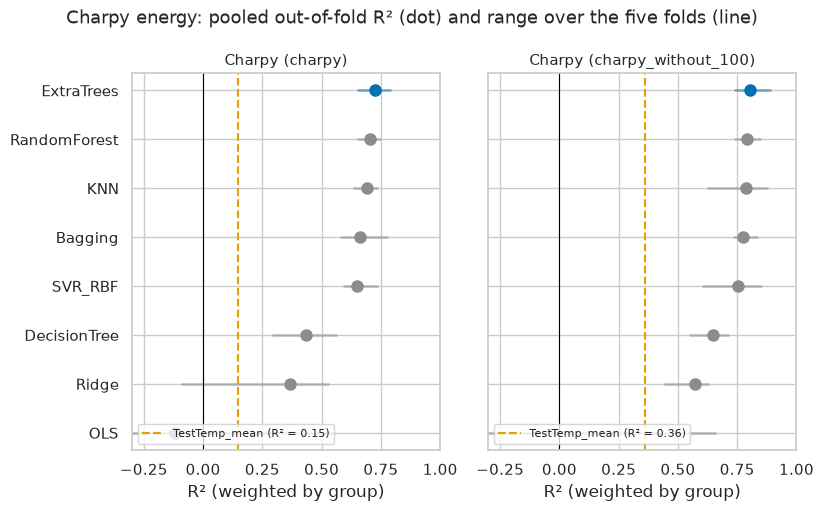

In [42]:
plot_r2_by_model([("charpy", "Charpy_toughness_J"), ("charpy_without_100", "Charpy_toughness_J")],
                 "Charpy energy: pooled out-of-fold R² (dot) and range over the five folds (line)")

The linear models fail on the Charpy task. The next cell looks at their largest errors: we list, for these tests, the variables whose value lies outside the range seen in the training folds.

In [43]:
ols = oof_all.query("task == 'charpy' and model == 'OLS'").assign(error=lambda d: d.y_pred - d.y_true)
worst = ols.loc[ols.error.abs().nlargest(10).index]
charpy_assigned = folds[folds.task.eq("charpy")]
numeric_charpy = [c for c in task_specs["charpy"]["features"] if c not in categorical_features_all]
out_of_range = []
for _, r in worst.iterrows():
    train_ids = charpy_assigned.loc[charpy_assigned.outer_fold.ne(r.outer_fold), "row_id"]
    train = df_ml.loc[train_ids, numeric_charpy]
    x = df_ml.loc[r.row_id, numeric_charpy]
    outside = [f"{c}={x[c]:g} (train {train[c].min():g}-{train[c].max():g})" for c in numeric_charpy
               if pd.notna(x[c]) and (x[c] < train[c].min() or x[c] > train[c].max())]
    out_of_range.append("; ".join(outside) or "none")
display(worst.assign(Type_of_weld=df_ml.loc[worst.row_id, "Type_of_weld"].to_numpy(),
                     Weld_ID=df_ml.loc[worst.row_id, "Weld_ID"].to_numpy(),
                     outside_training_range=out_of_range)
        [["outer_fold", "Weld_ID", "Type_of_weld", "y_true", "y_pred", "outside_training_range"]].round(1))

,outer_fold,Weld_ID,Type_of_weld,y_true,y_pred,outside_training_range
29021,4,Mart-Ga,FCA,6.0,-599.2,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29022,4,Mart-Gb,FCA,9.0,-587.6,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29023,4,Mart-Gc,FCA,19.0,-564.4,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29024,4,Mart-Gd,FCA,37.0,-541.2,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29025,4,Mart-Ge,FCA,56.0,-518.1,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29026,4,Mart-Gf,FCA,62.0,-494.9,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29027,4,Mart-Gg,FCA,68.0,-471.7,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29028,4,Mart-Gh,FCA,68.0,-448.5,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
29029,4,Mart-Gi,FCA,71.0,-436.9,Sulphur_S=0.14 (train 0.002-0.023); Phosphorus...
24263,1,Ditt-0.5rch2,SA,141.0,527.4,Post_weld_time_h=20 (train 0-14); Charpy_temp_...


**Reading of the toughness results.**

- **Tree ensembles are the best models**: ExtraTrees reaches R² = 0.73, RMSE 21 J and MAE 12 J on all the tests, followed by the random forest and bagging; KNN and SVR are slightly behind.
- **The test temperature explains part of the toughness; the weld explains the rest.** The baseline that only uses the mean energy at each test temperature reaches R² = 0.15, the best model 0.73. Once the test temperature is known, composition and process carry most of the predictable information. This is not in contradiction with the weak link between Charpy and the first PCA components (section 3.4): those components only describe linear directions of the inputs, without the temperature.
- **The 100 J values do not drive the result.** Without them, ExtraTrees still ranks first (R² = 0.80, RMSE 22 J, MAE 10 J) and the order of the models is almost unchanged. R² is higher only because the remaining values are more spread out (RMSE of the mean baseline 55 J instead of 40 J); the errors in joules are of the same order.
- **The linear models fail** (OLS R² = −0.12, Ridge 0.37). The table above shows why: the largest errors (predictions between −440 and −600 J) concern one family of FCA welds (`Mart-G*`) with 0.14 wt% sulphur and 0.25 wt% phosphorus, far outside the training range (at most 0.023 wt% sulphur). A linear model extrapolates the impurity coefficients and predicts physically impossible negative energies, whereas trees and kernels stay bounded by the training values. These impurity levels are about ten times the usual levels of weld metal: they are either an intentional embrittlement study or an encoding error, and should be checked in the source publication.
- In relative terms, the toughness is predicted less accurately than the strength (normalised RMSE 0.52 against 0.44), as expected in section 4.2.

### 6.6 Error analysis by weld type

Phase 3 showed that the weld types are separated in the input space, and 70% of the strength data are MMA welds. We check whether the best models are accurate for every weld type, or only for the majority family, by comparing their group-weighted MAE with the weld-type baseline.

In [44]:
def error_by_type(task):
    target_list = task_specs[task]["targets"]
    d = oof_all[oof_all.task.eq(task) & oof_all.model.isin([best_model[task], "WeldType_mean"])].copy()
    d["Type_of_weld"] = df_ml.loc[d.row_id, "Type_of_weld"].to_numpy()
    d["abs_error"] = (d.y_pred - d.y_true).abs()
    rows = []
    for (weld, model, target), g in d.groupby(["Type_of_weld", "model", "target"]):
        rows.append({"Type_of_weld": weld, "model": "best" if model == best_model[task] else "weld-type mean",
                     "target": SHORT[target], "MAE": np.average(g.abs_error, weights=group_weights(g.group)),
                     "rows": len(g), "groups": g.group.nunique()})
    table = pd.DataFrame(rows).pivot_table(index=["Type_of_weld", "rows", "groups"], columns=["target", "model"],
                                           values="MAE").round(1)
    return table.sort_index(level="rows", ascending=False)


print(f"Strength, best model = {best_model['strength']} (MAE weighted by group, MPa or %)")
display(error_by_type("strength"))
print(f"Charpy, best model = {best_model['charpy']} (MAE weighted by group, J)")
display(error_by_type("charpy"))

Strength, best model = SVR_RBF (MAE weighted by group, MPa or %)


target                   Elongation                  UTS                Yield  \
model                          best weld-type mean  best weld-type mean  best   
Type_of_weld rows groups                                                        
MMA          479  332           1.7            4.2  14.9           65.3  19.2   
SA           127  80            2.1            4.0  28.1           78.1  37.1   
TSA          24   21            3.1            5.1  29.4          109.2  50.4   
Other        18   12            2.9            3.0  49.5           87.8  67.8   
ShMA         10   10            1.5            2.4  12.0           30.8  17.0   
FCA          7    7             5.6            4.0  36.2           40.1  52.8   

target                                   
model                    weld-type mean  
Type_of_weld rows groups                 
MMA          479  332              61.4  
SA           127  80               60.3  
TSA          24   21              128.0  
Other        18   12               99.4  
ShMA         10   10               30.1  
FCA          7    7                49.4

Charpy, best model = ExtraTrees (MAE weighted by group, J)


target                   Charpy               
model                      best weld-type mean
Type_of_weld rows groups                      
MMA          653  260       9.7           26.3
TSA          63   16       20.2           41.5
FCA          63   7        31.8           53.4
SA           61   31       12.6           42.3
ShMA         20   10       21.4           36.0
Other        19   4        54.7           68.2

**Reading.**

- For strength, the SVR is much better than the weld-type baseline for almost every weld type, including the minority ones (TSA: yield MAE 50 MPa against 128 MPa). The errors are, however, two to three times larger for the rare types (SA, TSA, FCA, Other: yield MAE 37 to 68 MPa) than for the MMA welds (19 MPa) that dominate the data. The only case where the model is not better than the baseline is the elongation of the FCA welds (7 rows).
- For Charpy, the pattern is the same: MAE 10 J for the MMA welds, 13 J for SA, 20 to 32 J for TSA, ShMA and FCA, and 55 J for the 19 tests of the `Other` types (4 groups).
- Consequence: the global scores are mostly the scores of the MMA welds (72% of the strength rows, 74% of the Charpy tests). For a process that is rare in the database, the predictions are only indicative.

### 6.7 Conclusion: the most appropriate approach

**Strength (main objective).** The most appropriate approach is a supervised **SVR with RBF kernel** on the 25 preprocessed composition and process variables, with standardised targets and hyperparameters tuned by group cross-validation. On welds never seen in training, it predicts the yield and tensile strengths with R² ≈ 0.78 and 0.88 (RMSE 39 and 31 MPa) and the elongation with R² ≈ 0.74 (RMSE 2.6 %). Its advantage over ExtraTrees is small but significant. ExtraTrees remains a good alternative: slightly better on elongation, and the same family as the toughness model.

**Toughness (second objective).** The most appropriate approach is a tree ensemble, **ExtraTrees** (practically equivalent to the random forest), with the Charpy test temperature as an input: R² ≈ 0.73, RMSE ≈ 21 J, MAE ≈ 12 J. Its ranking does not depend on the questionable 100 J values.

**Two separate models**, as decided in Phase 4: strength and toughness are measured on almost disjoint sets of welds, and each model uses all its data.

**Methods not retained.** The linear models (too rigid, and dangerous when extrapolating), the single decision tree (unstable), and the graph-based semi-supervised regression (no gain over its supervised control on this database).

**Limits.** The scores are estimated on 462 (strength) and 328 (toughness) independent weld groups, mostly MMA welds. The errors are larger for rare weld types and for compositions at the edge of the database. A prediction should therefore come with a check of its domain of validity (range of each input in the training data): the failure of the linear models on the `Mart-G` welds shows what happens outside it.

### 6.8 What drives the predictions

To turn the models into recommendations, we look at which variables they use and how the predictions change with them. Two complementary tools are used, both on the best model of each task:

- **Permutation importance** [B4]: in each outer fold, the model with the selected hyperparameters is refitted on the training rows, and one input variable of the **test** rows is randomly permuted; the increase of the normalised RMSE measures how much the model relies on that variable for new welds. The permutation is done on the raw variables, before the preprocessing, so a variable and its missing indicator (and the one-hot columns of a category) are permuted together.
- **Partial dependence** [B5]: a model fitted on all the labeled welds (with the configuration selected most often in the outer folds) predicts every weld with one variable set to a given value, and the predictions are averaged. The curves show the average effect of a variable, the others being kept at their observed values. The grid covers the 5th to 95th percentiles of the observed values, to avoid extrapolation.

Two limits must be kept in mind. Both tools describe the **model**, not the physics: they show associations learned from observational data, collected in different studies, not causal effects. And correlated variables (sulphur and phosphorus, current, voltage and heat input) share their importance, and their partial dependence can involve combinations that do not exist in the data.

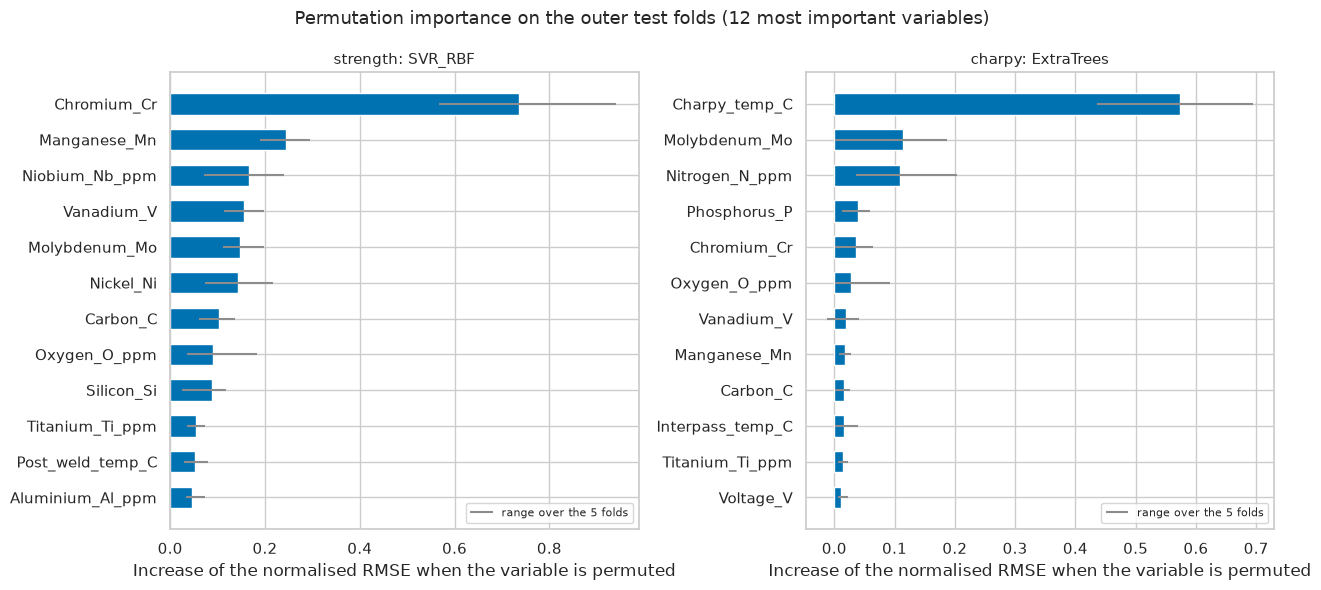

In [45]:
from sklearn.inspection import permutation_importance


def normalised_rmse_score(estimator, X, y):
    y = np.asarray(y, float).reshape(len(X), -1)
    pred = np.asarray(estimator.predict(X), float).reshape(y.shape)
    return -float(np.mean(np.sqrt(((y - pred) ** 2).mean(axis=0)) / y.std(axis=0)))


def fold_importance(task, n_repeats=10):
    spec, model_name = task_specs[task], best_model[task]
    base, _ = supervised_specs()[model_name]
    assigned = folds[folds.task.eq(task)]
    records = []
    for fold in range(1, N_OUTER + 1):
        params = json.loads(selected.query("task == @task and model == @model_name and outer_fold == @fold")
                            .parameters.iloc[0])
        train_ids = assigned.loc[assigned.outer_fold.ne(fold), "row_id"].to_numpy()
        test_ids = assigned.loc[assigned.outer_fold.eq(fold), "row_id"].to_numpy()
        model = pipeline(make_preprocessor(spec["features"]), clone(base).set_params(**params))
        model.fit(df_ml.loc[train_ids, spec["features"]],
                  fit_target(df_ml.loc[train_ids, spec["targets"]].to_numpy(float), model_name))
        result = permutation_importance(model, df_ml.loc[test_ids, spec["features"]],
                                        df_ml.loc[test_ids, spec["targets"]].to_numpy(float),
                                        scoring=normalised_rmse_score, n_repeats=n_repeats, random_state=SEED)
        records += [{"feature": f, "fold": fold, "importance": v}
                    for f, v in zip(spec["features"], result.importances_mean)]
    table = pd.DataFrame(records).groupby("feature").importance.agg(["mean", "min", "max"])
    return table.sort_values("mean", ascending=False)


importance = {task: fold_importance(task) for task in ["strength", "charpy"]}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, task in zip(axes, ["strength", "charpy"]):
    top = importance[task].head(12)[::-1]
    ax.barh(top.index, top["mean"], color=BLUE, height=0.6)
    ax.hlines(range(len(top)), top["min"], top["max"], color=GREY, linewidth=1.5, label="range over the 5 folds")
    ax.set_xlabel("Increase of the normalised RMSE when the variable is permuted")
    ax.set_title(f"{task}: {best_model[task]}", fontsize=11)
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("Permutation importance on the outer test folds (12 most important variables)", fontsize=13)
plt.tight_layout()
plt.show()

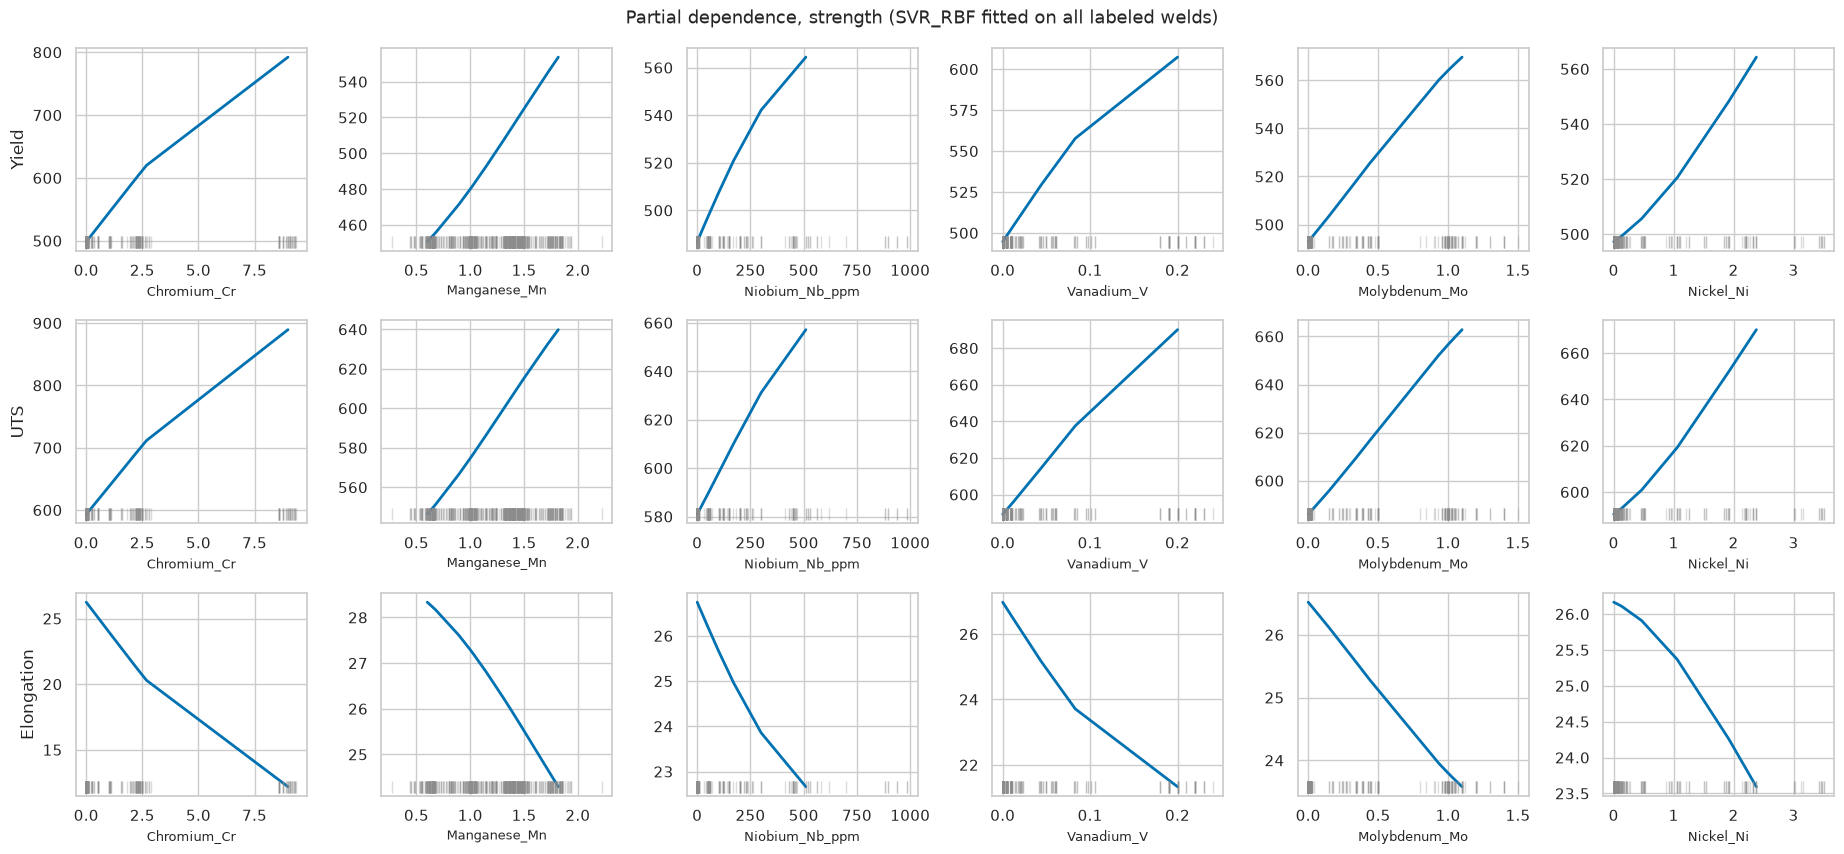

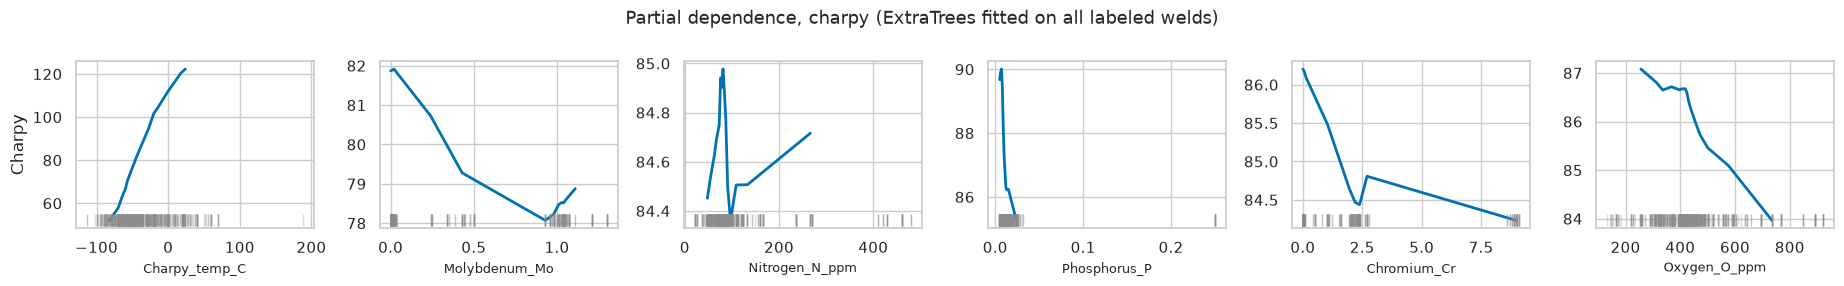

In [46]:
def final_model(task):
    """Best model refitted on all the labeled rows, with its most frequently selected configuration."""
    spec, model_name = task_specs[task], best_model[task]
    base, _ = supervised_specs()[model_name]
    params = json.loads(selected.query("task == @task and model == @model_name").parameters.mode().iloc[0])
    ids = np.asarray(spec["labeled"])
    model = pipeline(make_preprocessor(spec["features"]), clone(base).set_params(**params))
    model.fit(df_ml.loc[ids, spec["features"]], fit_target(df_ml.loc[ids, spec["targets"]].to_numpy(float), model_name))
    return model, df_ml.loc[ids, spec["features"]]


def partial_dependence_curve(model, X, feature, n_points=15):
    observed = X[feature].dropna()
    grid = np.unique(np.quantile(observed, np.linspace(0.05, 0.95, n_points)))
    curve = []
    for value in grid:
        X_value = X.copy()
        X_value[feature] = value
        curve.append(np.asarray(model.predict(X_value)).reshape(len(X), -1).mean(axis=0))
    return grid, np.array(curve), observed


def plot_partial_dependence(task, n_features=6):
    model, X = final_model(task)
    targets = task_specs[task]["targets"]
    numeric = [f for f in importance[task].index if f not in categorical_features_all][:n_features]
    fig, axes = plt.subplots(len(targets), len(numeric), figsize=(3.1 * len(numeric), 2.9 * len(targets)),
                             squeeze=False)
    for j, feature in enumerate(numeric):
        grid, curve, observed = partial_dependence_curve(model, X, feature)
        for i, target in enumerate(targets):
            ax = axes[i, j]
            ax.plot(grid, curve[:, i], color=BLUE, linewidth=2)
            # Rug: observed values (5th-95th percentiles are covered by the curve)
            ax.plot(observed, np.full(len(observed), curve[:, i].min()), "|", color=GREY, alpha=0.3, markersize=8)
            ax.set_xlabel(feature, fontsize=9)
            if j == 0:
                ax.set_ylabel(SHORT[target])
    fig.suptitle(f"Partial dependence, {task} ({best_model[task]} fitted on all labeled welds)", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_partial_dependence("strength")
plot_partial_dependence("charpy")

**Strength.** Chromium is by far the most important variable for the SVR, followed by manganese, niobium, vanadium, molybdenum, nickel and carbon; the process parameters matter much less, except the post-weld heat-treatment temperature. The partial dependences have the expected metallurgical directions: each alloying element **increases** the yield and tensile strengths and **decreases** the elongation, which is the strength/ductility trade-off seen in Phase 1. Over the observed ranges, the averaged effects on the yield strength are about +100 MPa for Mn from 0.6 to 1.8 wt%, +65 MPa for Ni from 0 to 2.4 wt%, +75 MPa for Mo from 0 to 1.1 wt%, +75 MPa for Nb from 0 to 500 ppm and +110 MPa for V from 0 to 0.2 wt%, with a loss of about 2.5 to 6 points of elongation each.

The chromium effect must be read with care. The data contain two populations: welds with less than about 2.5 wt% Cr, and 33 strength welds with about 9 wt% Cr (high-alloy, creep-resistant welds), with nothing in between. The curve between 2.5 and 9 wt% is an interpolation, and the importance of chromium mostly reflects the difference between these two families.

**Toughness.** The test temperature dominates: on average the predicted energy rises from about 55 J at −80 °C to about 120 J at +20 °C (the ductile-brittle transition). Then come molybdenum, nitrogen, phosphorus, chromium and oxygen. Their averaged effects are small compared with the temperature (a few joules): the toughness decreases when molybdenum (up to about 1 wt%), chromium, phosphorus (−5 J between 0.005 and 0.03 wt%) and oxygen (−3 J between 250 and 750 ppm) increase. The nitrogen curve is irregular and cannot be interpreted. These directions agree with welding metallurgy: impurities and oxide inclusions reduce the toughness, and strong alloying raises the strength at the expense of the toughness. The averaged effects are small because the effect of a variable depends on the others (interactions, captured by the trees but averaged out in a partial dependence).

### 6.9 Recommendations to obtain a good weld quality

These recommendations come from the selected models and agree with welding metallurgy. They are associations learned on historical data, valid within the range of the database, and should be confirmed by designed welding trials before being applied.

1. **Define quality as a compromise, for each application.** Strength and toughness move in opposite directions (section 4.1 and 6.8): the elements that raise the strength lower the elongation and, for molybdenum and chromium, the toughness. The composition and procedure should be chosen from the required minimum strength **and** the required Charpy energy at the service temperature, not by maximising one property.
2. **Reach the strength with moderate, combined alloying.** Manganese, nickel, molybdenum and micro-alloying (niobium, vanadium) all increase the strength, with smooth and roughly additive effects in the model. Highly alloyed welds (9 wt% Cr) are much stronger but much less ductile; they belong to another application (creep resistance) and should not be used to extrapolate to structural welds.
3. **Keep impurities and oxygen low to protect the toughness.** Phosphorus, sulphur (strongly correlated with phosphorus) and oxygen are associated with a lower Charpy energy; the welds with very high sulphur and phosphorus (`Mart-G`) absorb as little as 6 J. Clean consumables, good shielding by gas or flux, and low-impurity base metal are the levers.
4. **Specify and verify the toughness at the service temperature.** The test temperature is the main driver of the Charpy energy: a weld that is tough at 20 °C may be brittle at −40 °C. For cold-climate applications such as wind-turbine tubes, the acceptance test should be done at the lowest service temperature.
5. **Treat the process parameters as a secondary lever.** Once the composition is known, current, voltage, heat input and interpass temperature have a small importance in both models, within the ranges of the database; the post-weld heat-treatment temperature has a small but visible effect on strength.
6. **Use the models for screening, not as a substitute for testing.** They can pre-select compositions and procedures before trials, provided that (a) the predicted value is compared with the specification with a margin of at least one RMSE (about 40 MPa for the yield strength, about 20 J for the Charpy energy), and (b) a warning is raised when an input lies outside the range of the database.
7. **Improve the data.** Report the elements that are currently missing (imputed to zero), document the 100 J and 28 J values and the sulphur and phosphorus contents of the `Mart-G` welds, measure strength and toughness on the same welds (only 144 welds have both), and add welds from processes other than MMA. This would allow a joint model of the strength/toughness compromise and would help more than unlabeled data, which did not improve the predictions here.

## References

The references were consulted on 7 October 2026. The course material of Myriam Tami, in particular the lecture CM8, provides the assumptions of semi-supervised learning and the graph Laplacian; the references below support the adaptation to regression, the interpretation tools and the software.

### Articles and books

**[B1]** Belkin, M., Niyogi, P. and Sindhwani, V. (2006). *Manifold Regularization: A Geometric Framework for Learning from Labeled and Unlabeled Examples*. Journal of Machine Learning Research, 7, 2399–2434. [Article and PDF](https://www.jmlr.org/papers/v7/belkin06a.html), in particular sections 2 and 4.2.

The article combines a supervised risk with a geometric regularisation built from labeled and unlabeled inputs. Its extension to new observations motivates our inductive choice. Our implementation uses an explicit Nyström map and a quadratic penalty on its coefficients: it is a finite-dimensional adaptation, not an exact reproduction of LapRLS in a full RKHS. The rank, the kernel and the normalisation of the Laplacian are stated in the notebook.

**[B2]** Zhu, X., Ghahramani, Z. and Lafferty, J. (2003). *Semi-Supervised Learning Using Gaussian Fields and Harmonic Functions*. Proceedings of ICML, 912–919. [Authors' PDF](https://mlg.eng.cam.ac.uk/pub/pdf/ZhuGhaLaf03a.pdf).

This work justifies representing similarities with a graph and looking for functions that vary little along its edges. Pure propagation on a graph is the conceptual starting point; we keep a prediction function so that new welds, excluded from the training graph, can be evaluated.

**[B3]** van Engelen, J. E. and Hoos, H. H. (2020). *A survey on semi-supervised learning*. Machine Learning, 109, 373–440. [DOI](https://doi.org/10.1007/s10994-019-05855-6), [authors' PDF](https://ada.liacs.nl/papers/EngHoo19.pdf). Sections 4.1, 8.1 and 9.

The survey situates self-training, co-training and graph methods. Its section on regression notes that the real-valued functions of graph methods apply directly. Pseudo-labelling would require a confidence criterion for continuous outputs; the graph avoids introducing one. Unlabeled data can degrade the performance when the assumptions fail, which is why the evaluation includes supervised controls. COREG (Zhou and Li, 2005) is an alternative identified in this survey, not implemented here.

**[B4]** Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32. [DOI](https://doi.org/10.1023/A:1010933404324). Origin of the random forest and of the permutation importance used in section 6.8.

**[B5]** Friedman, J. H. (2001). *Greedy function approximation: a gradient boosting machine*. Annals of Statistics, 29(5), 1189–1232. [DOI](https://doi.org/10.1214/aos/1013203451). Introduces the partial dependence plots used in section 6.8.

**[B6]** Geurts, P., Ernst, D. and Wehenkel, L. (2006). *Extremely randomized trees*. Machine Learning, 63(1), 3–42. [DOI](https://doi.org/10.1007/s10994-006-6226-1). The ExtraTrees model of Phase 5.

**[B7]** Efron, B. and Tibshirani, R. J. (1993). *An Introduction to the Bootstrap*. Chapman & Hall. Percentile bootstrap intervals used in section 6.3 (here resampling whole weld groups).

### Data and documentation

**[D1]** Cool, T. and Bhadeshia, H. K. D. H. *MAP Data Library — MAP_DATA_WELD*. [Original documentation](https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html). Definition of the 44 columns, units, bibliographic origin and meaning of `N`. The document does not flag 100 J or 28 J as default values.

**[D2]** scikit-learn. [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) and [nested cross-validation example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html). Separation between selection and evaluation, and splits by groups.

**[D3]** scikit-learn. [Semi-supervised learning](https://scikit-learn.org/stable/modules/semi_supervised.html). `SelfTrainingClassifier`, `LabelPropagation` and `LabelSpreading` are classification tools, not applicable directly to our continuous outputs.

**[D4]** scikit-learn. [Kernel approximation](https://scikit-learn.org/stable/modules/kernel_approximation.html). The Nyström map gives a finite-dimensional kernel representation that can also transform new observations.

**[D5]** scikit-learn. [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html) and [partial dependence](https://scikit-learn.org/stable/modules/partial_dependence.html). Definitions and limits (correlated features, extrapolation) of the tools of section 6.8.